Cell 1 — Install packages

In [1]:
!pip -q install scikit-learn xgboost

Cell 2 — Imports

In [2]:
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid

from xgboost import XGBRegressor

Cell 3 — Output folder

In [3]:
OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)
print("Output folder:", OUT_DIR)

Output folder: data/21_final_gold_methodology


Cell 4 — Load files

In [4]:
df = pd.read_csv("round4_light_text_surprise_dataset.csv")
aligned_df = pd.read_csv("dataset_v2_aligned_finbert_updated.csv")
raw_emb = np.load("finbert_embeddings_raw_updated.npy")

print("Round4-light shape:", df.shape)
print("Aligned shape:", aligned_df.shape)
print("Raw embeddings shape:", raw_emb.shape)

assert len(aligned_df) == raw_emb.shape[0], "Embedding rows do not match aligned_df rows"

Round4-light shape: (2058, 46)
Aligned shape: (2247, 26)
Raw embeddings shape: (2247, 768)


Cell 5 — Standardise keys

In [5]:
for df_ in [df, aligned_df]:
    df_["ticker"] = df_["ticker"].astype(str).str.strip().str.upper()
    df_["filing_type"] = df_["filing_type"].astype(str).str.strip().str.upper()
    df_["filing_date"] = pd.to_datetime(df_["filing_date"], errors="coerce")

if "accession_number" in df.columns:
    df["accession_number"] = df["accession_number"].astype(str).str.strip()

if "accession_number" in aligned_df.columns:
    aligned_df["accession_number"] = aligned_df["accession_number"].astype(str).str.strip()

Cell 6 — Remove duplicate and stale columns

In [6]:
df = df.loc[:, ~df.columns.duplicated()].copy()

stale_cols = [c for c in df.columns if c.startswith("emb_idx") or c.startswith("finbert_pca_")]
print("Dropping stale columns:", stale_cols[:20], "... total =", len(stale_cols))

if len(stale_cols) > 0:
    df = df.drop(columns=stale_cols).copy()

print("Shape after stale-column cleanup:", df.shape)

Dropping stale columns: ['emb_idx'] ... total = 1
Shape after stale-column cleanup: (2058, 45)


Cell 7 — Merge fresh embedding index

In [7]:
aligned_df = aligned_df.copy()
aligned_df["emb_idx_from_aligned"] = np.arange(len(aligned_df))

merge_keys = ["ticker", "filing_date", "filing_type"]
if "accession_number" in df.columns and "accession_number" in aligned_df.columns:
    merge_keys.append("accession_number")

df = df.merge(
    aligned_df[merge_keys + ["emb_idx_from_aligned"]],
    on=merge_keys,
    how="left"
)

df["emb_idx"] = df["emb_idx_from_aligned"]
df = df.drop(columns=["emb_idx_from_aligned"])

print("Merged shape:", df.shape)
print("Missing emb_idx rows:", df["emb_idx"].isna().sum())

Merged shape: (2058, 46)
Missing emb_idx rows: 0


Cell 8 — Final cleaning and core variables

In [8]:
df = df.dropna(subset=["emb_idx"]).copy()
df["emb_idx"] = df["emb_idx"].astype(int)

df["filing_year"] = df["filing_date"].dt.year
df["filing_month"] = df["filing_date"].dt.month
df["quarter"] = df["filing_date"].dt.quarter
df["is_10k"] = (df["filing_type"] == "10-K").astype(int)

TARGET_RAW = "future_realized_vol_10d"
TARGET_LOG = "log_future_realized_vol_10d"

df = df[df["filing_date"].notna()].copy()
df = df[df[TARGET_RAW].notna()].copy()
df = df[df[TARGET_RAW] > 0].copy()
df[TARGET_LOG] = np.log(df[TARGET_RAW])

df = df.sort_values(["filing_date", "ticker"]).reset_index(drop=True)

print("Final working shape:", df.shape)
df.head()

Final working shape: (2058, 46)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,...,return_kurtosis_10d,log_price_tminus1,vol_ratio_5_20,vol_ratio_10_60,log_future_realized_vol_10d,prev_emb_idx,finbert_l2_centroid_hist,finbert_cosdist_prev,finbert_l2_prev,emb_idx
0,TJX,109198,2019-05-31,10-Q,0001628280-19-007432,2019,2,109198,162828019007432,TJX_20190531_10-Q_000162828019007432.txt,...,-0.346396,3.923161,1.280027,1.457337,-4.629500,1773.0,1.223323,0.009025,1.223323,1774
1,LOW,60667,2019-06-03,10-Q,0000060667-19-000086,2019,2,60667,6066719000086,LOW_20190603_10-Q_000006066719000086.txt,...,5.079343,4.535606,0.659109,1.971662,-4.396287,1100.0,1.847100,0.018421,1.847100,1101
2,CDNS,813672,2019-07-22,10-Q,0000813672-19-000022,2019,3,813672,81367219000022,CDNS_20190722_10-Q_000081367219000022.txt,...,4.396743,4.289363,0.852258,0.531649,-3.794480,402.0,0.136406,0.000094,0.136406,403
3,ISRG,1035267,2019-07-22,10-Q,0001035267-19-000088,2019,3,1035267,103526719000088,ISRG_20190722_10-Q_000103526719000088.txt,...,-0.904354,5.172017,1.567115,1.001232,-4.042480,930.0,0.234741,0.000280,0.234741,931
4,PLD,1045609,2019-07-22,10-Q,0001564590-19-025364,2019,3,1045609,156459019025364,PLD_20190722_10-Q_000156459019025364.txt,...,-0.378039,4.391234,1.107768,1.101398,-4.411159,1550.0,0.278215,0.000362,0.278215,1551


Cell 9 — Final untouched test split

In [9]:
test_start = pd.Timestamp("2023-01-01")

train_full = df.loc[df["filing_date"] < test_start].copy().reset_index(drop=True)
test_holdout = df.loc[df["filing_date"] >= test_start].copy().reset_index(drop=True)

print("Train-full rows:", len(train_full))
print("Test-holdout rows:", len(test_holdout))
print("Train-full range:", train_full["filing_date"].min(), "to", train_full["filing_date"].max())
print("Test-holdout range:", test_holdout["filing_date"].min(), "to", test_holdout["filing_date"].max())

Train-full rows: 1272
Test-holdout rows: 786
Train-full range: 2019-05-31 00:00:00 to 2022-12-29 00:00:00
Test-holdout range: 2023-01-05 00:00:00 to 2024-12-13 00:00:00


Cell 10 — Expanding validation folds

In [10]:
folds = [
    {
        "name": "fold1",
        "train_end": pd.Timestamp("2020-12-31"),
        "val_start": pd.Timestamp("2021-01-01"),
        "val_end": pd.Timestamp("2021-12-31")
    },
    {
        "name": "fold2",
        "train_end": pd.Timestamp("2021-06-30"),
        "val_start": pd.Timestamp("2021-07-01"),
        "val_end": pd.Timestamp("2022-06-30")
    },
    {
        "name": "fold3",
        "train_end": pd.Timestamp("2021-12-31"),
        "val_start": pd.Timestamp("2022-01-01"),
        "val_end": pd.Timestamp("2022-12-31")
    }
]

for f in folds:
    tr = train_full[train_full["filing_date"] <= f["train_end"]]
    va = train_full[(train_full["filing_date"] >= f["val_start"]) & (train_full["filing_date"] <= f["val_end"])]
    print(f["name"], "train:", len(tr), "val:", len(va))

fold1 train: 496 val: 380
fold2 train: 675 val: 383
fold3 train: 876 val: 396


Cell 11 — Feature blocks

In [11]:
price_plus_context_features = [
    "past_return_5d",
    "past_return_10d",
    "past_return_20d",
    "abs_past_return_10d",
    "past_realized_vol_5d",
    "past_realized_vol_10d",
    "past_realized_vol_20d",
    "past_realized_vol_30d",
    "past_realized_vol_60d",
    "mean_abs_return_5d",
    "mean_abs_return_10d",
    "max_abs_return_10d",
    "return_skew_10d",
    "return_kurtosis_10d",
    "log_price_tminus1",
    "vol_ratio_5_20",
    "vol_ratio_10_60",
    "is_10k",
    "log_text_length_words"
]

lm_features = [
    "lm_negative",
    "lm_positive",
    "lm_uncertainty",
    "lm_net_sentiment"
]

safe_light_surprise_features = [
    "finbert_l2_centroid_hist",
    "finbert_cosdist_prev",
    "finbert_l2_prev",
    "finbert_pca_delta_l2"
]

if "abs_delta_lm_uncertainty" in df.columns:
    safe_light_surprise_features.append("abs_delta_lm_uncertainty")

safe_light_surprise_features = [c for c in safe_light_surprise_features if c in df.columns]

categorical_features = ["quarter", "filing_month", "filing_year"]

PCA_COMPONENTS = 15
pca_feature_names = [f"finbert_pca_{i+1}" for i in range(PCA_COMPONENTS)]

print("Using surprise features:", safe_light_surprise_features)

def get_feature_columns(dataset_name):
    if dataset_name == "model1_price_only":
        return price_plus_context_features + categorical_features
    elif dataset_name == "model2_price_lm":
        return price_plus_context_features + lm_features + categorical_features
    elif dataset_name == "model3_price_lm_finbert":
        return price_plus_context_features + lm_features + pca_feature_names + categorical_features
    elif dataset_name == "model4_price_lm_finbert_surprise":
        return price_plus_context_features + lm_features + pca_feature_names + safe_light_surprise_features + categorical_features
    else:
        raise ValueError(dataset_name)

dataset_names = [
    "model1_price_only",
    "model2_price_lm",
    "model3_price_lm_finbert",
    "model4_price_lm_finbert_surprise"
]

for name in dataset_names:
    print(name, len(get_feature_columns(name)))

Using surprise features: ['finbert_l2_centroid_hist', 'finbert_cosdist_prev', 'finbert_l2_prev']
model1_price_only 22
model2_price_lm 26
model3_price_lm_finbert 41
model4_price_lm_finbert_surprise 44


Cell 12 — Metric helper

In [12]:
def evaluate_regression_both_scales(y_true_log, y_pred_log):
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)

    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "RMSE_log": rmse_log,
        "MAE_log": mae_log,
        "R2_log": r2_log,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

Cell 13 — Preprocessor helper

In [13]:
def make_preprocessors(cols, categorical_features):
    numeric_cols = [c for c in cols if c not in categorical_features]
    categorical_cols = [c for c in categorical_features if c in cols]

    linear_preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols)
        ],
        remainder="drop"
    )

    tree_preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols)
        ],
        remainder="drop"
    )

    return linear_preprocessor, tree_preprocessor

Cell 14 — Split-safe PCA + split-safe finbert_pca_delta_l2

In [14]:
def add_split_safe_finbert_features(train_part, other_part, raw_emb, n_components=15):
    train_part = train_part.copy().reset_index(drop=True)
    other_part = other_part.copy().reset_index(drop=True)

    train_emb = raw_emb[train_part["emb_idx"].to_numpy()]
    other_emb = raw_emb[other_part["emb_idx"].to_numpy()]

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_emb)
    other_scaled = scaler.transform(other_emb)

    pca = PCA(n_components=n_components, random_state=42)
    train_pca = pca.fit_transform(train_scaled)
    other_pca = pca.transform(other_scaled)

    pca_cols = [f"finbert_pca_{i+1}" for i in range(n_components)]

    train_aug = pd.concat([train_part, pd.DataFrame(train_pca, columns=pca_cols)], axis=1)
    other_aug = pd.concat([other_part, pd.DataFrame(other_pca, columns=pca_cols)], axis=1)

    train_aug["_split"] = "train"
    other_aug["_split"] = "other"

    combined = pd.concat([train_aug, other_aug], ignore_index=True)
    combined = combined.sort_values(["ticker", "filing_date"]).reset_index(drop=True)

    for col in pca_cols:
        combined[f"prev_{col}"] = combined.groupby("ticker")[col].shift(1)
        combined[f"delta_{col}"] = combined[col] - combined[f"prev_{col}"]

    delta_cols = [f"delta_{c}" for c in pca_cols]
    combined["finbert_pca_delta_l2"] = np.sqrt((combined[delta_cols] ** 2).sum(axis=1))

    train_out = combined[combined["_split"] == "train"].drop(columns=["_split"]).reset_index(drop=True)
    other_out = combined[combined["_split"] == "other"].drop(columns=["_split"]).reset_index(drop=True)

    return train_out, other_out, scaler, pca, pca_cols

Cell 15 — Naive holdout benchmarks

In [15]:
y_train = train_full[TARGET_LOG].copy()
y_test = test_holdout[TARGET_LOG].copy()

naive_mean_pred = np.repeat(y_train.mean(), len(y_test))
naive_mean_metrics = evaluate_regression_both_scales(y_test, naive_mean_pred)

naive_lag_pred = np.log(test_holdout["past_realized_vol_20d"].clip(lower=1e-8))
naive_lag_metrics = evaluate_regression_both_scales(y_test, naive_lag_pred)

benchmarks_holdout = pd.DataFrame([
    {"model": "NaiveMean", "dataset": "naive_mean", **naive_mean_metrics},
    {"model": "NaiveLagVol20d", "dataset": "naive_lag_vol20d", **naive_lag_metrics}
])

benchmarks_holdout

,model,dataset,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2
0,NaiveMean,naive_mean,0.555191,0.451961,-0.291755,0.010143,0.006944,-0.046412
1,NaiveLagVol20d,naive_lag_vol20d,0.500118,0.393605,-0.048191,0.010436,0.006499,-0.107727


Cell 16 — Tuning grids

In [16]:
rf_grid = {
    "n_estimators": [300, 500],
    "max_depth": [8, 10, 14],
    "min_samples_leaf": [3, 5, 8],
    "max_features": ["sqrt", 0.5]
}

enet_grid = {
    "alpha": [0.0003, 0.001, 0.003, 0.01],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

xgb_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}

Cell 17 — Validation tuning with expanding folds

In [17]:
cv_results = []
best_params = {}

for dataset_name in dataset_names:
    print(f"\nTuning dataset: {dataset_name}")

    # LinearRegression benchmark
    lr_scores = []

    for f in folds:
        fold_train = train_full[train_full["filing_date"] <= f["train_end"]].copy().reset_index(drop=True)
        fold_val = train_full[
            (train_full["filing_date"] >= f["val_start"]) &
            (train_full["filing_date"] <= f["val_end"])
        ].copy().reset_index(drop=True)

        if dataset_name in ["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]:
            fold_train, fold_val, _, _, _ = add_split_safe_finbert_features(
                fold_train, fold_val, raw_emb, n_components=PCA_COMPONENTS
            )

        cols = get_feature_columns(dataset_name)

        X_tr = fold_train[cols]
        X_va = fold_val[cols]
        y_tr = fold_train[TARGET_LOG]
        y_va = fold_val[TARGET_LOG]

        linear_preprocessor, _ = make_preprocessors(cols, categorical_features)

        lr_pipe = Pipeline([
            ("prep", linear_preprocessor),
            ("model", LinearRegression())
        ])
        lr_pipe.fit(X_tr, y_tr)
        preds = lr_pipe.predict(X_va)
        lr_scores.append(evaluate_regression_both_scales(y_va, preds))

    lr_avg = pd.DataFrame(lr_scores).mean().to_dict()
    lr_avg["model"] = "LinearRegression"
    lr_avg["dataset"] = dataset_name
    cv_results.append(lr_avg)

    # ElasticNet tuning
    best_enet_rmse = np.inf
    best_enet_params = None

    for params in ParameterGrid(enet_grid):
        fold_scores = []

        for f in folds:
            fold_train = train_full[train_full["filing_date"] <= f["train_end"]].copy().reset_index(drop=True)
            fold_val = train_full[
                (train_full["filing_date"] >= f["val_start"]) &
                (train_full["filing_date"] <= f["val_end"])
            ].copy().reset_index(drop=True)

            if dataset_name in ["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]:
                fold_train, fold_val, _, _, _ = add_split_safe_finbert_features(
                    fold_train, fold_val, raw_emb, n_components=PCA_COMPONENTS
                )

            cols = get_feature_columns(dataset_name)

            X_tr = fold_train[cols]
            X_va = fold_val[cols]
            y_tr = fold_train[TARGET_LOG]
            y_va = fold_val[TARGET_LOG]

            linear_preprocessor, _ = make_preprocessors(cols, categorical_features)

            enet_pipe = Pipeline([
                ("prep", linear_preprocessor),
                ("model", ElasticNet(max_iter=20000, random_state=42, **params))
            ])
            enet_pipe.fit(X_tr, y_tr)
            preds = enet_pipe.predict(X_va)
            fold_scores.append(evaluate_regression_both_scales(y_va, preds))

        avg_metrics = pd.DataFrame(fold_scores).mean()
        if avg_metrics["RMSE_log"] < best_enet_rmse:
            best_enet_rmse = avg_metrics["RMSE_log"]
            best_enet_params = params

    best_params[(dataset_name, "ElasticNet")] = best_enet_params

    # score best ElasticNet
    fold_scores = []
    for f in folds:
        fold_train = train_full[train_full["filing_date"] <= f["train_end"]].copy().reset_index(drop=True)
        fold_val = train_full[
            (train_full["filing_date"] >= f["val_start"]) &
            (train_full["filing_date"] <= f["val_end"])
        ].copy().reset_index(drop=True)

        if dataset_name in ["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]:
            fold_train, fold_val, _, _, _ = add_split_safe_finbert_features(
                fold_train, fold_val, raw_emb, n_components=PCA_COMPONENTS
            )

        cols = get_feature_columns(dataset_name)
        X_tr = fold_train[cols]
        X_va = fold_val[cols]
        y_tr = fold_train[TARGET_LOG]
        y_va = fold_val[TARGET_LOG]

        linear_preprocessor, _ = make_preprocessors(cols, categorical_features)

        enet_pipe = Pipeline([
            ("prep", linear_preprocessor),
            ("model", ElasticNet(max_iter=20000, random_state=42, **best_enet_params))
        ])
        enet_pipe.fit(X_tr, y_tr)
        preds = enet_pipe.predict(X_va)
        fold_scores.append(evaluate_regression_both_scales(y_va, preds))

    enet_avg = pd.DataFrame(fold_scores).mean().to_dict()
    enet_avg["model"] = "ElasticNet"
    enet_avg["dataset"] = dataset_name
    cv_results.append(enet_avg)

    # RandomForest tuning
    best_rf_rmse = np.inf
    best_rf_params = None

    for params in ParameterGrid(rf_grid):
        fold_scores = []

        for f in folds:
            fold_train = train_full[train_full["filing_date"] <= f["train_end"]].copy().reset_index(drop=True)
            fold_val = train_full[
                (train_full["filing_date"] >= f["val_start"]) &
                (train_full["filing_date"] <= f["val_end"])
            ].copy().reset_index(drop=True)

            if dataset_name in ["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]:
                fold_train, fold_val, _, _, _ = add_split_safe_finbert_features(
                    fold_train, fold_val, raw_emb, n_components=PCA_COMPONENTS
                )

            cols = get_feature_columns(dataset_name)
            X_tr = fold_train[cols]
            X_va = fold_val[cols]
            y_tr = fold_train[TARGET_LOG]
            y_va = fold_val[TARGET_LOG]

            _, tree_preprocessor = make_preprocessors(cols, categorical_features)

            rf_pipe = Pipeline([
                ("prep", tree_preprocessor),
                ("model", RandomForestRegressor(random_state=42, n_jobs=-1, **params))
            ])
            rf_pipe.fit(X_tr, y_tr)
            preds = rf_pipe.predict(X_va)
            fold_scores.append(evaluate_regression_both_scales(y_va, preds))

        avg_metrics = pd.DataFrame(fold_scores).mean()
        if avg_metrics["RMSE_log"] < best_rf_rmse:
            best_rf_rmse = avg_metrics["RMSE_log"]
            best_rf_params = params

    best_params[(dataset_name, "RandomForest")] = best_rf_params

    # score best RF
    fold_scores = []
    for f in folds:
        fold_train = train_full[train_full["filing_date"] <= f["train_end"]].copy().reset_index(drop=True)
        fold_val = train_full[
            (train_full["filing_date"] >= f["val_start"]) &
            (train_full["filing_date"] <= f["val_end"])
        ].copy().reset_index(drop=True)

        if dataset_name in ["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]:
            fold_train, fold_val, _, _, _ = add_split_safe_finbert_features(
                fold_train, fold_val, raw_emb, n_components=PCA_COMPONENTS
            )

        cols = get_feature_columns(dataset_name)
        X_tr = fold_train[cols]
        X_va = fold_val[cols]
        y_tr = fold_train[TARGET_LOG]
        y_va = fold_val[TARGET_LOG]

        _, tree_preprocessor = make_preprocessors(cols, categorical_features)

        rf_pipe = Pipeline([
            ("prep", tree_preprocessor),
            ("model", RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params))
        ])
        rf_pipe.fit(X_tr, y_tr)
        preds = rf_pipe.predict(X_va)
        fold_scores.append(evaluate_regression_both_scales(y_va, preds))

    rf_avg = pd.DataFrame(fold_scores).mean().to_dict()
    rf_avg["model"] = "RandomForest"
    rf_avg["dataset"] = dataset_name
    cv_results.append(rf_avg)

    # XGBoost tuning
    best_xgb_rmse = np.inf
    best_xgb_params = None

    for params in ParameterGrid(xgb_grid):
        fold_scores = []

        for f in folds:
            fold_train = train_full[train_full["filing_date"] <= f["train_end"]].copy().reset_index(drop=True)
            fold_val = train_full[
                (train_full["filing_date"] >= f["val_start"]) &
                (train_full["filing_date"] <= f["val_end"])
            ].copy().reset_index(drop=True)

            if dataset_name in ["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]:
                fold_train, fold_val, _, _, _ = add_split_safe_finbert_features(
                    fold_train, fold_val, raw_emb, n_components=PCA_COMPONENTS
                )

            cols = get_feature_columns(dataset_name)
            X_tr = fold_train[cols]
            X_va = fold_val[cols]
            y_tr = fold_train[TARGET_LOG]
            y_va = fold_val[TARGET_LOG]

            _, tree_preprocessor = make_preprocessors(cols, categorical_features)
            X_tr_prep = tree_preprocessor.fit_transform(X_tr)
            X_va_prep = tree_preprocessor.transform(X_va)

            xgb_model = XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
                reg_alpha=0.0,
                reg_lambda=1.0,
                **params
            )
            xgb_model.fit(X_tr_prep, y_tr)
            preds = xgb_model.predict(X_va_prep)
            fold_scores.append(evaluate_regression_both_scales(y_va, preds))

        avg_metrics = pd.DataFrame(fold_scores).mean()
        if avg_metrics["RMSE_log"] < best_xgb_rmse:
            best_xgb_rmse = avg_metrics["RMSE_log"]
            best_xgb_params = params

    best_params[(dataset_name, "XGBoost")] = best_xgb_params

    # score best XGB
    fold_scores = []
    for f in folds:
        fold_train = train_full[train_full["filing_date"] <= f["train_end"]].copy().reset_index(drop=True)
        fold_val = train_full[
            (train_full["filing_date"] >= f["val_start"]) &
            (train_full["filing_date"] <= f["val_end"])
        ].copy().reset_index(drop=True)

        if dataset_name in ["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]:
            fold_train, fold_val, _, _, _ = add_split_safe_finbert_features(
                fold_train, fold_val, raw_emb, n_components=PCA_COMPONENTS
            )

        cols = get_feature_columns(dataset_name)
        X_tr = fold_train[cols]
        X_va = fold_val[cols]
        y_tr = fold_train[TARGET_LOG]
        y_va = fold_val[TARGET_LOG]

        _, tree_preprocessor = make_preprocessors(cols, categorical_features)
        X_tr_prep = tree_preprocessor.fit_transform(X_tr)
        X_va_prep = tree_preprocessor.transform(X_va)

        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            reg_alpha=0.0,
            reg_lambda=1.0,
            **best_xgb_params
        )
        xgb_model.fit(X_tr_prep, y_tr)
        preds = xgb_model.predict(X_va_prep)
        fold_scores.append(evaluate_regression_both_scales(y_va, preds))

    xgb_avg = pd.DataFrame(fold_scores).mean().to_dict()
    xgb_avg["model"] = "XGBoost"
    xgb_avg["dataset"] = dataset_name
    cv_results.append(xgb_avg)

cv_results_df = pd.DataFrame(cv_results).sort_values("RMSE_log").reset_index(drop=True)
cv_results_df


Tuning dataset: model1_price_only

Tuning dataset: model2_price_lm

Tuning dataset: model3_price_lm_finbert

Tuning dataset: model4_price_lm_finbert_surprise


,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2,model,dataset
0,0.411729,0.333275,0.355674,0.008322,0.006106,0.371690,RandomForest,model1_price_only
1,0.412746,0.333908,0.352790,0.008400,0.006131,0.360883,RandomForest,model2_price_lm
2,0.413170,0.333740,0.353048,0.008426,0.006138,0.356055,RandomForest,model3_price_lm_finbert
3,0.413592,0.333626,0.351527,0.008432,0.006138,0.355322,RandomForest,model4_price_lm_finbert_surprise
4,0.416860,0.335684,0.334522,0.008548,0.006223,0.323722,XGBoost,model2_price_lm
5,0.416860,0.336767,0.336812,0.008570,0.006236,0.323166,XGBoost,model4_price_lm_finbert_surprise
6,0.417706,0.338154,0.334588,0.008638,0.006288,0.311919,XGBoost,model3_price_lm_finbert
7,0.418274,0.337232,0.332546,0.008505,0.006226,0.330751,XGBoost,model1_price_only
8,0.422362,0.342233,0.320643,0.008978,0.006434,0.268318,LinearRegression,model4_price_lm_finbert_surprise
9,0.422805,0.342310,0.319672,0.009009,0.006436,0.264418,LinearRegression,model3_price_lm_finbert


Cell 18 — Save validation results and best params

In [18]:
cv_results_df.to_csv(f"{OUT_DIR}/cv_results.csv", index=False)

best_params_df = pd.DataFrame([
    {"dataset": k[0], "model": k[1], **v}
    for k, v in best_params.items()
])
best_params_df.to_csv(f"{OUT_DIR}/best_params.csv", index=False)

print("Saved CV results and best params.")
best_params_df

Saved CV results and best params.


,dataset,model,alpha,l1_ratio,max_depth,max_features,min_samples_leaf,n_estimators,colsample_bytree,learning_rate,min_child_weight,subsample
0,model1_price_only,ElasticNet,0.01,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model1_price_only,RandomForest,NaN,NaN,10.0,sqrt,5.0,300.0,NaN,NaN,NaN,NaN
2,model1_price_only,XGBoost,NaN,NaN,3.0,NaN,NaN,300.0,0.8,0.03,3.0,0.9
3,model2_price_lm,ElasticNet,0.01,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,model2_price_lm,RandomForest,NaN,NaN,14.0,sqrt,5.0,500.0,NaN,NaN,NaN,NaN
5,model2_price_lm,XGBoost,NaN,NaN,3.0,NaN,NaN,300.0,0.9,0.03,3.0,0.8
6,model3_price_lm_finbert,ElasticNet,0.01,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,model3_price_lm_finbert,RandomForest,NaN,NaN,14.0,0.5,3.0,300.0,NaN,NaN,NaN,NaN
8,model3_price_lm_finbert,XGBoost,NaN,NaN,3.0,NaN,NaN,300.0,0.8,0.03,1.0,0.8
9,model4_price_lm_finbert_surprise,ElasticNet,0.01,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell 19 — Build final split-safe train/test features

In [19]:
train_final, test_final, finbert_scaler, finbert_pca, pca_cols_final = add_split_safe_finbert_features(
    train_full, test_holdout, raw_emb, n_components=PCA_COMPONENTS
)

print("Train final shape:", train_final.shape)
print("Test final shape:", test_final.shape)
print("Explained variance:", finbert_pca.explained_variance_ratio_.sum())

Train final shape: (1272, 92)
Test final shape: (786, 92)
Explained variance: 0.8128598


Cell 20 — Save split-safe artifacts

In [20]:
train_final.to_csv(f"{OUT_DIR}/train_final.csv", index=False)
test_final.to_csv(f"{OUT_DIR}/test_final.csv", index=False)

with open(f"{OUT_DIR}/finbert_scaler_train.pkl", "wb") as f:
    pickle.dump(finbert_scaler, f)

with open(f"{OUT_DIR}/finbert_pca_train.pkl", "wb") as f:
    pickle.dump(finbert_pca, f)

print("Saved split-safe artifacts.")

Saved split-safe artifacts.


Cell 21 — Final locked holdout evaluation

In [21]:
final_results = []
saved_final_models = {}

y_train = train_final[TARGET_LOG].copy()
y_test = test_final[TARGET_LOG].copy()

naive_mean_pred = np.repeat(y_train.mean(), len(y_test))
naive_mean_metrics = evaluate_regression_both_scales(y_test, naive_mean_pred)
final_results.append({"model": "NaiveMean", "dataset": "naive_mean", **naive_mean_metrics})

naive_lag_pred = np.log(test_final["past_realized_vol_20d"].clip(lower=1e-8))
naive_lag_metrics = evaluate_regression_both_scales(y_test, naive_lag_pred)
final_results.append({"model": "NaiveLagVol20d", "dataset": "naive_lag_vol20d", **naive_lag_metrics})

for dataset_name in dataset_names:
    cols = get_feature_columns(dataset_name)

    X_train = train_final[cols].copy()
    X_test = test_final[cols].copy()

    y_train = train_final[TARGET_LOG].copy()
    y_test = test_final[TARGET_LOG].copy()

    linear_preprocessor, tree_preprocessor = make_preprocessors(cols, categorical_features)

    lr_pipe = Pipeline([
        ("prep", linear_preprocessor),
        ("model", LinearRegression())
    ])
    lr_pipe.fit(X_train, y_train)
    lr_preds = lr_pipe.predict(X_test)
    final_results.append({"model": "LinearRegression", "dataset": dataset_name, **evaluate_regression_both_scales(y_test, lr_preds)})
    saved_final_models[("LinearRegression", dataset_name)] = lr_pipe

    enet_pipe = Pipeline([
        ("prep", linear_preprocessor),
        ("model", ElasticNet(max_iter=20000, random_state=42, **best_params[(dataset_name, "ElasticNet")]))
    ])
    enet_pipe.fit(X_train, y_train)
    enet_preds = enet_pipe.predict(X_test)
    final_results.append({"model": "ElasticNet", "dataset": dataset_name, **evaluate_regression_both_scales(y_test, enet_preds)})
    saved_final_models[("ElasticNet", dataset_name)] = enet_pipe

    rf_pipe = Pipeline([
        ("prep", tree_preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1, **best_params[(dataset_name, "RandomForest")]))
    ])
    rf_pipe.fit(X_train, y_train)
    rf_preds = rf_pipe.predict(X_test)
    final_results.append({"model": "RandomForest", "dataset": dataset_name, **evaluate_regression_both_scales(y_test, rf_preds)})
    saved_final_models[("RandomForest", dataset_name)] = rf_pipe

    X_train_tree = tree_preprocessor.fit_transform(X_train)
    X_test_tree = tree_preprocessor.transform(X_test)

    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        reg_alpha=0.0,
        reg_lambda=1.0,
        **best_params[(dataset_name, "XGBoost")]
    )
    xgb_model.fit(X_train_tree, y_train)
    xgb_preds = xgb_model.predict(X_test_tree)
    final_results.append({"model": "XGBoost", "dataset": dataset_name, **evaluate_regression_both_scales(y_test, xgb_preds)})
    saved_final_models[("XGBoost", dataset_name)] = (tree_preprocessor, xgb_model)

final_results_df = pd.DataFrame(final_results).sort_values("RMSE_log").reset_index(drop=True)
final_results_df

,model,dataset,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2
0,RandomForest,model3_price_lm_finbert,0.437074,0.345732,0.199421,0.008786,0.005359,0.214823
1,RandomForest,model4_price_lm_finbert_surprise,0.437697,0.346166,0.197135,0.008765,0.005366,0.218668
2,XGBoost,model2_price_lm,0.440378,0.344375,0.187271,0.008896,0.005366,0.195032
3,RandomForest,model2_price_lm,0.440488,0.348397,0.186867,0.008812,0.005376,0.210301
4,RandomForest,model1_price_only,0.441848,0.349608,0.181838,0.008814,0.005410,0.209822
5,XGBoost,model3_price_lm_finbert,0.442560,0.345661,0.179197,0.008826,0.005383,0.207768
6,XGBoost,model1_price_only,0.445007,0.348916,0.170095,0.008951,0.005431,0.185172
7,XGBoost,model4_price_lm_finbert_surprise,0.446646,0.351260,0.163969,0.008848,0.005478,0.203767
8,ElasticNet,model2_price_lm,0.473251,0.372879,0.061408,0.009533,0.005812,0.075650
9,ElasticNet,model1_price_only,0.474807,0.375712,0.055224,0.009465,0.005848,0.088887


Cell 22 — Direct Model 3 vs Model 4 comparison

In [22]:
model3_vs_model4 = final_results_df[
    final_results_df["dataset"].isin(["model3_price_lm_finbert", "model4_price_lm_finbert_surprise"])
].copy().sort_values(["model", "RMSE_log"]).reset_index(drop=True)

model3_vs_model4

,model,dataset,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2
0,ElasticNet,model3_price_lm_finbert,0.475131,0.376099,0.053935,0.009425,0.005880,0.096503
1,ElasticNet,model4_price_lm_finbert_surprise,0.475449,0.376392,0.052669,0.009430,0.005887,0.095638
2,LinearRegression,model3_price_lm_finbert,0.480882,0.381184,0.030894,0.009510,0.005984,0.080156
3,LinearRegression,model4_price_lm_finbert_surprise,0.481686,0.382324,0.027651,0.009528,0.006009,0.076674
4,RandomForest,model3_price_lm_finbert,0.437074,0.345732,0.199421,0.008786,0.005359,0.214823
5,RandomForest,model4_price_lm_finbert_surprise,0.437697,0.346166,0.197135,0.008765,0.005366,0.218668
6,XGBoost,model3_price_lm_finbert,0.442560,0.345661,0.179197,0.008826,0.005383,0.207768
7,XGBoost,model4_price_lm_finbert_surprise,0.446646,0.351260,0.163969,0.008848,0.005478,0.203767


Cell 23 — Test-set bootstrap confidence intervals

In [23]:
def bootstrap_metric_ci(y_true_log, y_pred_log, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true_log)

    rmse_logs = []
    r2_logs = []

    idx = np.arange(n)
    for _ in range(n_boot):
        b = rng.choice(idx, size=n, replace=True)
        yt = y_true_log[b]
        yp = y_pred_log[b]

        rmse_logs.append(np.sqrt(mean_squared_error(yt, yp)))
        r2_logs.append(r2_score(yt, yp))

    return {
        "RMSE_log_mean": float(np.mean(rmse_logs)),
        "RMSE_log_p2_5": float(np.percentile(rmse_logs, 2.5)),
        "RMSE_log_p97_5": float(np.percentile(rmse_logs, 97.5)),
        "R2_log_mean": float(np.mean(r2_logs)),
        "R2_log_p2_5": float(np.percentile(r2_logs, 2.5)),
        "R2_log_p97_5": float(np.percentile(r2_logs, 97.5)),
    }

ci_rows = []

for dataset_name in dataset_names:
    rf_model = saved_final_models[("RandomForest", dataset_name)]
    preds = rf_model.predict(test_final[get_feature_columns(dataset_name)])
    ci = bootstrap_metric_ci(test_final[TARGET_LOG].to_numpy(), preds, n_boot=1000, seed=42)
    ci["dataset"] = dataset_name
    ci_rows.append(ci)

ci_df = pd.DataFrame(ci_rows).sort_values("RMSE_log_mean").reset_index(drop=True)
ci_df

,RMSE_log_mean,RMSE_log_p2_5,RMSE_log_p97_5,R2_log_mean,R2_log_p2_5,R2_log_p97_5,dataset
0,0.437121,0.414208,0.460896,0.195956,0.121832,0.265760,model3_price_lm_finbert
1,0.437717,0.415239,0.461425,0.193740,0.119495,0.263642,model4_price_lm_finbert_surprise
2,0.440593,0.417625,0.464360,0.183155,0.112495,0.251922,model2_price_lm
3,0.441903,0.418362,0.465416,0.178255,0.104639,0.249527,model1_price_only


Cell 24 — High-volatility regime analysis

In [24]:
threshold = train_final["past_realized_vol_20d"].quantile(0.7)

test_final = test_final.copy()
test_final["high_vol_regime"] = (test_final["past_realized_vol_20d"] >= threshold).astype(int)

regime_rows = []

for dataset_name in dataset_names:
    rf_model = saved_final_models[("RandomForest", dataset_name)]
    preds = rf_model.predict(test_final[get_feature_columns(dataset_name)])

    tmp = test_final.copy()
    tmp["pred_log"] = preds

    for regime_value, regime_name in [(0, "low_vol"), (1, "high_vol")]:
        sub = tmp[tmp["high_vol_regime"] == regime_value]
        metrics = evaluate_regression_both_scales(sub[TARGET_LOG], sub["pred_log"])
        metrics["dataset"] = dataset_name
        metrics["regime"] = regime_name
        regime_rows.append(metrics)

regime_df = pd.DataFrame(regime_rows).sort_values(["regime", "RMSE_log"]).reset_index(drop=True)
regime_df

,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2,dataset,regime
0,0.448823,0.337220,0.179369,0.015147,0.008302,0.085033,model4_price_lm_finbert_surprise,high_vol
1,0.450456,0.337902,0.173385,0.015219,0.008316,0.076290,model3_price_lm_finbert,high_vol
2,0.458377,0.346712,0.144057,0.015251,0.008397,0.072515,model2_price_lm,high_vol
3,0.459277,0.351261,0.140694,0.015195,0.008515,0.079276,model1_price_only,high_vol
4,0.434119,0.347429,0.020122,0.006613,0.004718,0.103629,model3_price_lm_finbert,low_vol
5,0.435249,0.348105,0.015016,0.006614,0.004730,0.103318,model4_price_lm_finbert_surprise,low_vol
6,0.436514,0.348762,0.009283,0.006638,0.004721,0.096744,model2_price_lm,low_vol
7,0.437979,0.349250,0.002621,0.006670,0.004737,0.088039,model1_price_only,low_vol


Cell 25 — Feature importance for best RandomForest

In [25]:
rf_results = final_results_df[
    (final_results_df["model"] == "RandomForest") &
    (final_results_df["dataset"].isin(dataset_names))
].copy().sort_values("RMSE_log").reset_index(drop=True)

best_rf_dataset = rf_results.iloc[0]["dataset"]
print("Best RF dataset:", best_rf_dataset)

rf_best = saved_final_models[("RandomForest", best_rf_dataset)]

prep = rf_best.named_steps["prep"]
model = rf_best.named_steps["model"]

feature_names = prep.get_feature_names_out()
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

feat_imp.head(40)

Best RF dataset: model3_price_lm_finbert


,feature,importance
0,num__mean_abs_return_10d,0.114935
1,num__past_realized_vol_30d,0.106286
2,num__past_realized_vol_60d,0.100369
3,num__past_realized_vol_20d,0.098922
4,num__mean_abs_return_5d,0.039702
5,num__past_return_20d,0.025573
6,num__past_realized_vol_10d,0.022996
7,num__past_return_5d,0.022374
8,num__past_return_10d,0.021366
9,num__return_kurtosis_10d,0.018855


Cell 26 — Save outputs

In [26]:
final_results_df.to_csv(f"{OUT_DIR}/final_results.csv", index=False)
model3_vs_model4.to_csv(f"{OUT_DIR}/model3_vs_model4.csv", index=False)
ci_df.to_csv(f"{OUT_DIR}/rf_bootstrap_ci.csv", index=False)
regime_df.to_csv(f"{OUT_DIR}/rf_regime_analysis.csv", index=False)
feat_imp.to_csv(f"{OUT_DIR}/feature_importance_best_rf.csv", index=False)

print("Saved all final outputs.")

Saved all final outputs.


Cell 27 — Download outputs

In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/cv_results.csv")
files.download(f"{OUT_DIR}/best_params.csv")
files.download(f"{OUT_DIR}/final_results.csv")
files.download(f"{OUT_DIR}/model3_vs_model4.csv")
files.download(f"{OUT_DIR}/rf_bootstrap_ci.csv")
files.download(f"{OUT_DIR}/rf_regime_analysis.csv")
files.download(f"{OUT_DIR}/feature_importance_best_rf.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Step 1 — Regime comparison table for dissertation

reg = regime_df.copy()

# keep only the models we want to compare
keep = ["model1_price_only", "model3_price_lm_finbert", "model4_price_lm_finbert_surprise"]
reg = reg[reg["dataset"].isin(keep)].copy()

# pivot to compare by regime
pivot = reg.pivot(index="dataset", columns="regime", values="RMSE_log").reset_index()

# extract values
m1_low = pivot.loc[pivot["dataset"] == "model1_price_only", "low_vol"].iloc[0]
m1_high = pivot.loc[pivot["dataset"] == "model1_price_only", "high_vol"].iloc[0]

m3_low = pivot.loc[pivot["dataset"] == "model3_price_lm_finbert", "low_vol"].iloc[0]
m3_high = pivot.loc[pivot["dataset"] == "model3_price_lm_finbert", "high_vol"].iloc[0]

m4_low = pivot.loc[pivot["dataset"] == "model4_price_lm_finbert_surprise", "low_vol"].iloc[0]
m4_high = pivot.loc[pivot["dataset"] == "model4_price_lm_finbert_surprise", "high_vol"].iloc[0]

summary = pd.DataFrame({
    "comparison": [
        "Model 3 vs Model 1",
        "Model 3 vs Model 1",
        "Model 4 vs Model 3",
        "Model 4 vs Model 3"
    ],
    "regime": [
        "low_vol",
        "high_vol",
        "low_vol",
        "high_vol"
    ],
    "reference_model_rmse_log": [
        m1_low,
        m1_high,
        m3_low,
        m3_high
    ],
    "comparison_model_rmse_log": [
        m3_low,
        m3_high,
        m4_low,
        m4_high
    ]
})

summary["absolute_change_rmse_log"] = (
    summary["comparison_model_rmse_log"] - summary["reference_model_rmse_log"]
)

summary["pct_change_vs_reference"] = (
    summary["absolute_change_rmse_log"] / summary["reference_model_rmse_log"]
) * 100

summary

,comparison,regime,reference_model_rmse_log,comparison_model_rmse_log,absolute_change_rmse_log,pct_change_vs_reference
0,Model 3 vs Model 1,low_vol,0.437979,0.434119,-0.003860,-0.881230
1,Model 3 vs Model 1,high_vol,0.459277,0.450456,-0.008821,-1.920624
2,Model 4 vs Model 3,low_vol,0.434119,0.435249,0.001130,0.260207
3,Model 4 vs Model 3,high_vol,0.450456,0.448823,-0.001633,-0.362615


When Does Text Matter

In [28]:
# ============================================================
# When does text matter? — subgroup helper for all 4 models
# ============================================================

def subgroup_compare_all_models(test_df, subgroup_col, subgroup_name_map=None):
    rows = []

    model1 = saved_final_models[("RandomForest", "model1_price_only")]
    model2 = saved_final_models[("RandomForest", "model2_price_lm")]
    model3 = saved_final_models[("RandomForest", "model3_price_lm_finbert")]
    model4 = saved_final_models[("RandomForest", "model4_price_lm_finbert_surprise")]

    preds_m1 = model1.predict(test_df[get_feature_columns("model1_price_only")])
    preds_m2 = model2.predict(test_df[get_feature_columns("model2_price_lm")])
    preds_m3 = model3.predict(test_df[get_feature_columns("model3_price_lm_finbert")])
    preds_m4 = model4.predict(test_df[get_feature_columns("model4_price_lm_finbert_surprise")])

    tmp = test_df.copy()
    tmp["pred_m1"] = preds_m1
    tmp["pred_m2"] = preds_m2
    tmp["pred_m3"] = preds_m3
    tmp["pred_m4"] = preds_m4

    subgroup_values = list(pd.Series(tmp[subgroup_col].dropna().unique()).sort_values())

    for g in subgroup_values:
        sub = tmp[tmp[subgroup_col] == g].copy()
        label = subgroup_name_map[g] if subgroup_name_map is not None else str(g)

        m1 = evaluate_regression_both_scales(sub[TARGET_LOG], sub["pred_m1"])
        m2 = evaluate_regression_both_scales(sub[TARGET_LOG], sub["pred_m2"])
        m3 = evaluate_regression_both_scales(sub[TARGET_LOG], sub["pred_m3"])
        m4 = evaluate_regression_both_scales(sub[TARGET_LOG], sub["pred_m4"])

        rows.append({
            "test": subgroup_col,
            "group": label,
            "n_obs": len(sub),

            "model1_rmse_log": m1["RMSE_log"],
            "model2_rmse_log": m2["RMSE_log"],
            "model3_rmse_log": m3["RMSE_log"],
            "model4_rmse_log": m4["RMSE_log"],

            "model1_r2_log": m1["R2_log"],
            "model2_r2_log": m2["R2_log"],
            "model3_r2_log": m3["R2_log"],
            "model4_r2_log": m4["R2_log"],

            "model2_minus_model1_rmse_log": m2["RMSE_log"] - m1["RMSE_log"],
            "model3_minus_model1_rmse_log": m3["RMSE_log"] - m1["RMSE_log"],
            "model3_minus_model2_rmse_log": m3["RMSE_log"] - m2["RMSE_log"],
            "model4_minus_model3_rmse_log": m4["RMSE_log"] - m3["RMSE_log"],

            "model2_vs_model1_pct_change": ((m2["RMSE_log"] - m1["RMSE_log"]) / m1["RMSE_log"]) * 100,
            "model3_vs_model1_pct_change": ((m3["RMSE_log"] - m1["RMSE_log"]) / m1["RMSE_log"]) * 100,
            "model3_vs_model2_pct_change": ((m3["RMSE_log"] - m2["RMSE_log"]) / m2["RMSE_log"]) * 100,
            "model4_vs_model3_pct_change": ((m4["RMSE_log"] - m3["RMSE_log"]) / m3["RMSE_log"]) * 100
        })

    return pd.DataFrame(rows)

In [29]:
# ============================================================
# Build subgroup indicators on train and test
# ============================================================

train_sub = train_final.copy()
test_sub = test_final.copy()

# 1) High vs low LM uncertainty
unc_threshold = train_sub["lm_uncertainty"].median()
test_sub["high_lm_uncertainty"] = (test_sub["lm_uncertainty"] >= unc_threshold).astype(int)

# 2) High vs low semantic shift
shift_threshold = train_sub["finbert_l2_prev"].median()
test_sub["high_semantic_shift"] = (test_sub["finbert_l2_prev"] >= shift_threshold).astype(int)

# 3) 10-K vs 10-Q
test_sub["filing_group"] = test_sub["is_10k"].map({1: "10-K", 0: "10-Q"})

# 4) Long vs short MD&A
length_threshold = train_sub["log_text_length_words"].median()
test_sub["long_mda"] = (test_sub["log_text_length_words"] >= length_threshold).astype(int)

print("LM uncertainty threshold:", unc_threshold)
print("Semantic shift threshold:", shift_threshold)
print("MD&A length threshold:", length_threshold)

LM uncertainty threshold: 0.011734579943097099
Semantic shift threshold: 0.9628539979457856
MD&A length threshold: 9.048820941084843


In [30]:
# ============================================================
# Run subgroup comparisons for all 4 models
# ============================================================

uncertainty_results = subgroup_compare_all_models(
    test_sub,
    subgroup_col="high_lm_uncertainty",
    subgroup_name_map={0: "low_uncertainty", 1: "high_uncertainty"}
)

semantic_shift_results = subgroup_compare_all_models(
    test_sub,
    subgroup_col="high_semantic_shift",
    subgroup_name_map={0: "low_semantic_shift", 1: "high_semantic_shift"}
)

filing_type_results = subgroup_compare_all_models(
    test_sub,
    subgroup_col="filing_group"
)

length_results = subgroup_compare_all_models(
    test_sub,
    subgroup_col="long_mda",
    subgroup_name_map={0: "short_mda", 1: "long_mda"}
)

print("Uncertainty test")
display(uncertainty_results)

print("Semantic shift test")
display(semantic_shift_results)

print("Filing type test")
display(filing_type_results)

print("Length test")
display(length_results)

Uncertainty test


,test,group,n_obs,model1_rmse_log,model2_rmse_log,model3_rmse_log,model4_rmse_log,model1_r2_log,model2_r2_log,model3_r2_log,model4_r2_log,model2_minus_model1_rmse_log,model3_minus_model1_rmse_log,model3_minus_model2_rmse_log,model4_minus_model3_rmse_log,model2_vs_model1_pct_change,model3_vs_model1_pct_change,model3_vs_model2_pct_change,model4_vs_model3_pct_change
0,high_lm_uncertainty,low_uncertainty,374,0.426645,0.424674,0.417725,0.420293,0.134864,0.142841,0.170660,0.160432,-0.001971,-0.008920,-0.006948,0.002568,-0.462067,-2.090630,-1.636123,0.614737
1,high_lm_uncertainty,high_uncertainty,412,0.455209,0.454367,0.453924,0.452918,0.196227,0.199198,0.200757,0.204298,-0.000842,-0.001284,-0.000442,-0.001007,-0.184981,-0.282174,-0.097373,-0.221751


Semantic shift test


,test,group,n_obs,model1_rmse_log,model2_rmse_log,model3_rmse_log,model4_rmse_log,model1_r2_log,model2_r2_log,model3_r2_log,model4_r2_log,model2_minus_model1_rmse_log,model3_minus_model1_rmse_log,model3_minus_model2_rmse_log,model4_minus_model3_rmse_log,model2_vs_model1_pct_change,model3_vs_model1_pct_change,model3_vs_model2_pct_change,model4_vs_model3_pct_change
0,high_semantic_shift,low_semantic_shift,405,0.430103,0.431453,0.425805,0.424727,0.228333,0.223479,0.243679,0.247503,0.001350,-0.004298,-0.005649,-0.001078,0.313992,-0.999362,-1.309243,-0.253146
1,high_semantic_shift,high_semantic_shift,381,0.453999,0.449892,0.448743,0.451076,0.108883,0.124933,0.129398,0.120319,-0.004107,-0.005256,-0.001149,0.002334,-0.904676,-1.157793,-0.255427,0.520048


Filing type test


,test,group,n_obs,model1_rmse_log,model2_rmse_log,model3_rmse_log,model4_rmse_log,model1_r2_log,model2_r2_log,model3_r2_log,model4_r2_log,model2_minus_model1_rmse_log,model3_minus_model1_rmse_log,model3_minus_model2_rmse_log,model4_minus_model3_rmse_log,model2_vs_model1_pct_change,model3_vs_model1_pct_change,model3_vs_model2_pct_change,model4_vs_model3_pct_change
0,filing_group,10-K,164,0.475414,0.470480,0.472280,0.474174,-0.097709,-0.075041,-0.083283,-0.091987,-0.004934,-0.003134,0.001800,0.001894,-1.037880,-0.659285,0.382565,0.400974
1,filing_group,10-Q,622,0.432563,0.432233,0.427308,0.427562,0.238608,0.239771,0.256996,0.256114,-0.000331,-0.005255,-0.004925,0.000254,-0.076414,-1.214910,-1.139367,0.059334


Length test


,test,group,n_obs,model1_rmse_log,model2_rmse_log,model3_rmse_log,model4_rmse_log,model1_r2_log,model2_r2_log,model3_r2_log,model4_r2_log,model2_minus_model1_rmse_log,model3_minus_model1_rmse_log,model3_minus_model2_rmse_log,model4_minus_model3_rmse_log,model2_vs_model1_pct_change,model3_vs_model1_pct_change,model3_vs_model2_pct_change,model4_vs_model3_pct_change
0,long_mda,short_mda,436,0.451498,0.448992,0.447624,0.447434,0.227970,0.236517,0.241162,0.241808,-0.002506,-0.003874,-0.001368,-0.000190,-0.555047,-0.858036,-0.304679,-0.042537
1,long_mda,long_mda,350,0.429522,0.429658,0.423564,0.425257,0.079577,0.078998,0.104939,0.097768,0.000135,-0.005959,-0.006094,0.001693,0.031489,-1.387314,-1.418357,0.399776


In [31]:
# ============================================================
# Combine all subgroup results
# ============================================================

when_text_matters_all_df = pd.concat([
    uncertainty_results,
    semantic_shift_results,
    filing_type_results,
    length_results
], axis=0, ignore_index=True)

when_text_matters_all_df = when_text_matters_all_df[
    [
        "test",
        "group",
        "n_obs",

        "model1_rmse_log",
        "model2_rmse_log",
        "model3_rmse_log",
        "model4_rmse_log",

        "model2_minus_model1_rmse_log",
        "model3_minus_model1_rmse_log",
        "model3_minus_model2_rmse_log",
        "model4_minus_model3_rmse_log",

        "model2_vs_model1_pct_change",
        "model3_vs_model1_pct_change",
        "model3_vs_model2_pct_change",
        "model4_vs_model3_pct_change",

        "model1_r2_log",
        "model2_r2_log",
        "model3_r2_log",
        "model4_r2_log"
    ]
].copy()

when_text_matters_all_df

,test,group,n_obs,model1_rmse_log,model2_rmse_log,model3_rmse_log,model4_rmse_log,model2_minus_model1_rmse_log,model3_minus_model1_rmse_log,model3_minus_model2_rmse_log,model4_minus_model3_rmse_log,model2_vs_model1_pct_change,model3_vs_model1_pct_change,model3_vs_model2_pct_change,model4_vs_model3_pct_change,model1_r2_log,model2_r2_log,model3_r2_log,model4_r2_log
0,high_lm_uncertainty,low_uncertainty,374,0.426645,0.424674,0.417725,0.420293,-0.001971,-0.008920,-0.006948,0.002568,-0.462067,-2.090630,-1.636123,0.614737,0.134864,0.142841,0.170660,0.160432
1,high_lm_uncertainty,high_uncertainty,412,0.455209,0.454367,0.453924,0.452918,-0.000842,-0.001284,-0.000442,-0.001007,-0.184981,-0.282174,-0.097373,-0.221751,0.196227,0.199198,0.200757,0.204298
2,high_semantic_shift,low_semantic_shift,405,0.430103,0.431453,0.425805,0.424727,0.001350,-0.004298,-0.005649,-0.001078,0.313992,-0.999362,-1.309243,-0.253146,0.228333,0.223479,0.243679,0.247503
3,high_semantic_shift,high_semantic_shift,381,0.453999,0.449892,0.448743,0.451076,-0.004107,-0.005256,-0.001149,0.002334,-0.904676,-1.157793,-0.255427,0.520048,0.108883,0.124933,0.129398,0.120319
4,filing_group,10-K,164,0.475414,0.470480,0.472280,0.474174,-0.004934,-0.003134,0.001800,0.001894,-1.037880,-0.659285,0.382565,0.400974,-0.097709,-0.075041,-0.083283,-0.091987
5,filing_group,10-Q,622,0.432563,0.432233,0.427308,0.427562,-0.000331,-0.005255,-0.004925,0.000254,-0.076414,-1.214910,-1.139367,0.059334,0.238608,0.239771,0.256996,0.256114
6,long_mda,short_mda,436,0.451498,0.448992,0.447624,0.447434,-0.002506,-0.003874,-0.001368,-0.000190,-0.555047,-0.858036,-0.304679,-0.042537,0.227970,0.236517,0.241162,0.241808
7,long_mda,long_mda,350,0.429522,0.429658,0.423564,0.425257,0.000135,-0.005959,-0.006094,0.001693,0.031489,-1.387314,-1.418357,0.399776,0.079577,0.078998,0.104939,0.097768


In [32]:
# ============================================================
# Rounded display version
# ============================================================

when_text_matters_all_display = when_text_matters_all_df.copy()

round_cols = [
    "model1_rmse_log",
    "model2_rmse_log",
    "model3_rmse_log",
    "model4_rmse_log",

    "model2_minus_model1_rmse_log",
    "model3_minus_model1_rmse_log",
    "model3_minus_model2_rmse_log",
    "model4_minus_model3_rmse_log",

    "model2_vs_model1_pct_change",
    "model3_vs_model1_pct_change",
    "model3_vs_model2_pct_change",
    "model4_vs_model3_pct_change",

    "model1_r2_log",
    "model2_r2_log",
    "model3_r2_log",
    "model4_r2_log"
]

when_text_matters_all_display[round_cols] = when_text_matters_all_display[round_cols].round(6)
when_text_matters_all_display

,test,group,n_obs,model1_rmse_log,model2_rmse_log,model3_rmse_log,model4_rmse_log,model2_minus_model1_rmse_log,model3_minus_model1_rmse_log,model3_minus_model2_rmse_log,model4_minus_model3_rmse_log,model2_vs_model1_pct_change,model3_vs_model1_pct_change,model3_vs_model2_pct_change,model4_vs_model3_pct_change,model1_r2_log,model2_r2_log,model3_r2_log,model4_r2_log
0,high_lm_uncertainty,low_uncertainty,374,0.426645,0.424674,0.417725,0.420293,-0.001971,-0.008920,-0.006948,0.002568,-0.462067,-2.090630,-1.636123,0.614737,0.134864,0.142841,0.170660,0.160432
1,high_lm_uncertainty,high_uncertainty,412,0.455209,0.454367,0.453924,0.452918,-0.000842,-0.001284,-0.000442,-0.001007,-0.184981,-0.282174,-0.097373,-0.221751,0.196227,0.199198,0.200757,0.204298
2,high_semantic_shift,low_semantic_shift,405,0.430103,0.431453,0.425805,0.424727,0.001350,-0.004298,-0.005649,-0.001078,0.313992,-0.999362,-1.309243,-0.253146,0.228333,0.223479,0.243679,0.247503
3,high_semantic_shift,high_semantic_shift,381,0.453999,0.449892,0.448743,0.451076,-0.004107,-0.005256,-0.001149,0.002334,-0.904676,-1.157793,-0.255427,0.520048,0.108883,0.124933,0.129398,0.120319
4,filing_group,10-K,164,0.475414,0.470480,0.472280,0.474174,-0.004934,-0.003134,0.001800,0.001894,-1.037880,-0.659285,0.382565,0.400974,-0.097709,-0.075041,-0.083283,-0.091987
5,filing_group,10-Q,622,0.432563,0.432233,0.427308,0.427562,-0.000331,-0.005255,-0.004925,0.000254,-0.076414,-1.214910,-1.139367,0.059334,0.238608,0.239771,0.256996,0.256114
6,long_mda,short_mda,436,0.451498,0.448992,0.447624,0.447434,-0.002506,-0.003874,-0.001368,-0.000190,-0.555047,-0.858036,-0.304679,-0.042537,0.227970,0.236517,0.241162,0.241808
7,long_mda,long_mda,350,0.429522,0.429658,0.423564,0.425257,0.000135,-0.005959,-0.006094,0.001693,0.031489,-1.387314,-1.418357,0.399776,0.079577,0.078998,0.104939,0.097768


In [33]:
# ============================================================
# Save subgroup analysis outputs
# ============================================================

when_text_matters_all_df.to_csv(f"{OUT_DIR}/when_text_matters_all_models_full.csv", index=False)
when_text_matters_all_display.to_csv(f"{OUT_DIR}/when_text_matters_all_models_display.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/when_text_matters_all_models_full.csv")
print(f"{OUT_DIR}/when_text_matters_all_models_display.csv")

Saved:
data/21_final_gold_methodology/when_text_matters_all_models_full.csv
data/21_final_gold_methodology/when_text_matters_all_models_display.csv


In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/when_text_matters_all_models_full.csv")
files.download(f"{OUT_DIR}/when_text_matters_all_models_display.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

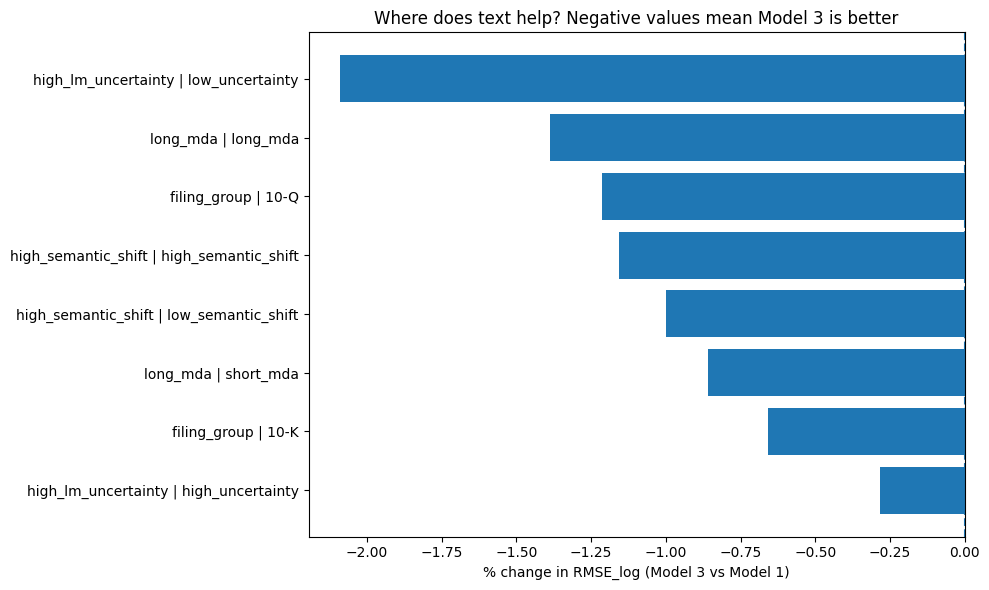

In [34]:
# ============================================================
# Chart: Model 3 vs Model 1
# ============================================================

import matplotlib.pyplot as plt

plot_df = when_text_matters_all_df.copy()
plot_df["label"] = plot_df["test"] + " | " + plot_df["group"]

plot_df = plot_df.sort_values("model3_vs_model1_pct_change").reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["model3_vs_model1_pct_change"])
plt.axvline(0, linestyle="--")
plt.xlabel("% change in RMSE_log (Model 3 vs Model 1)")
plt.ylabel("")
plt.title("Where does text help? Negative values mean Model 3 is better")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# Error analysis — build holdout predictions
# ============================================================

err_df = test_final.copy()

rf_m1 = saved_final_models[("RandomForest", "model1_price_only")]
rf_m3 = saved_final_models[("RandomForest", "model3_price_lm_finbert")]
rf_m4 = saved_final_models[("RandomForest", "model4_price_lm_finbert_surprise")]

err_df["pred_m1_log"] = rf_m1.predict(err_df[get_feature_columns("model1_price_only")])
err_df["pred_m3_log"] = rf_m3.predict(err_df[get_feature_columns("model3_price_lm_finbert")])
err_df["pred_m4_log"] = rf_m4.predict(err_df[get_feature_columns("model4_price_lm_finbert_surprise")])

err_df["y_true_log"] = err_df[TARGET_LOG]

err_df["pred_m1"] = np.exp(err_df["pred_m1_log"])
err_df["pred_m3"] = np.exp(err_df["pred_m3_log"])
err_df["pred_m4"] = np.exp(err_df["pred_m4_log"])
err_df["y_true"] = np.exp(err_df["y_true_log"])

print("Error-analysis dataframe shape:", err_df.shape)
err_df.head()

Error-analysis dataframe shape: (786, 101)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,...,finbert_pca_delta_l2,high_vol_regime,pred_m1_log,pred_m3_log,pred_m4_log,y_true_log,pred_m1,pred_m3,pred_m4,y_true
0,AAPL,320193,2023-02-03,10-Q,0000320193-23-000006,2023,1,320193,32019323000006,AAPL_20230203_10-Q_000032019323000006.txt,...,19.634344,0,-3.985679,-4.018993,-4.037453,-4.264965,0.018580,0.017971,0.017642,0.014052
1,AAPL,320193,2023-05-05,10-Q,0000320193-23-000064,2023,2,320193,32019323000064,AAPL_20230505_10-Q_000032019323000064.txt,...,7.628702,0,-4.390753,-4.320422,-4.308289,-4.968558,0.012391,0.013294,0.013457,0.006953
2,AAPL,320193,2023-08-04,10-Q,0000320193-23-000077,2023,3,320193,32019323000077,AAPL_20230804_10-Q_000032019323000077.txt,...,3.464370,0,-4.474457,-4.399311,-4.407505,-4.728428,0.011396,0.012286,0.012186,0.008840
3,AAPL,320193,2023-11-03,10-K,0000320193-23-000106,2023,4,320193,32019323000106,AAPL_20231103_10-K_000032019323000106.txt,...,11.189098,0,-4.340861,-4.336796,-4.358296,-4.642905,0.013025,0.013078,0.012800,0.009630
4,AAPL,320193,2024-02-02,10-Q,0000320193-24-000006,2024,1,320193,32019324000006,AAPL_20240202_10-Q_000032019324000006.txt,...,10.387492,0,-4.193146,-4.219933,-4.219249,-4.903932,0.015099,0.014700,0.014710,0.007417


In [36]:
# ============================================================
# Error columns
# ============================================================

for model_tag in ["m1", "m3", "m4"]:
    err_df[f"error_{model_tag}_log"] = err_df[f"pred_{model_tag}_log"] - err_df["y_true_log"]
    err_df[f"abs_error_{model_tag}_log"] = err_df[f"error_{model_tag}_log"].abs()

    err_df[f"error_{model_tag}"] = err_df[f"pred_{model_tag}"] - err_df["y_true"]
    err_df[f"abs_error_{model_tag}"] = err_df[f"error_{model_tag}"].abs()

# positive value = later model reduced error
err_df["m3_vs_m1_abs_error_gain_log"] = err_df["abs_error_m1_log"] - err_df["abs_error_m3_log"]
err_df["m4_vs_m3_abs_error_gain_log"] = err_df["abs_error_m3_log"] - err_df["abs_error_m4_log"]

print("Created error columns.")

Created error columns.


In [37]:
# ============================================================
# Average error reduction summary
# ============================================================

error_summary = pd.DataFrame({
    "comparison": [
        "Model 3 vs Model 1",
        "Model 4 vs Model 3"
    ],
    "mean_abs_error_reference_log": [
        err_df["abs_error_m1_log"].mean(),
        err_df["abs_error_m3_log"].mean()
    ],
    "mean_abs_error_comparison_log": [
        err_df["abs_error_m3_log"].mean(),
        err_df["abs_error_m4_log"].mean()
    ]
})

error_summary["absolute_change_abs_error_log"] = (
    error_summary["mean_abs_error_comparison_log"] - error_summary["mean_abs_error_reference_log"]
)

error_summary["pct_change_vs_reference"] = (
    error_summary["absolute_change_abs_error_log"] / error_summary["mean_abs_error_reference_log"]
) * 100

error_summary

,comparison,mean_abs_error_reference_log,mean_abs_error_comparison_log,absolute_change_abs_error_log,pct_change_vs_reference
0,Model 3 vs Model 1,0.349608,0.345732,-0.003876,-1.108658
1,Model 4 vs Model 3,0.345732,0.346166,0.000434,0.125463


In [38]:
# ============================================================
# Worst Model 3 prediction cases
# ============================================================

worst_m3_cases = err_df.sort_values("abs_error_m3_log", ascending=False).copy()

worst_cols_to_show = [
    "ticker",
    "filing_date",
    "filing_type",
    "future_realized_vol_10d",
    "y_true_log",
    "pred_m1_log",
    "pred_m3_log",
    "pred_m4_log",
    "abs_error_m1_log",
    "abs_error_m3_log",
    "abs_error_m4_log",
    "lm_uncertainty",
    "lm_net_sentiment",
    "log_text_length_words",
    "finbert_l2_prev",
    "finbert_l2_centroid_hist"
]

worst_cols_to_show = [c for c in worst_cols_to_show if c in worst_m3_cases.columns]

worst_m3_cases[worst_cols_to_show].head(20)

,ticker,filing_date,filing_type,future_realized_vol_10d,y_true_log,pred_m1_log,pred_m3_log,pred_m4_log,abs_error_m1_log,abs_error_m3_log,abs_error_m4_log,lm_uncertainty,lm_net_sentiment,log_text_length_words,finbert_l2_prev,finbert_l2_centroid_hist
96,APP,2024-11-06,10-Q,0.147441,-1.914324,-3.625527,-3.664884,-3.617483,1.711202,1.750559,1.703159,0.011763,0.006334,9.064274,0.284046,1.043371
624,SBUX,2024-04-30,10-Q,0.052725,-2.942656,-4.478521,-4.568510,-4.531154,1.535865,1.625854,1.588498,0.018103,-0.005287,8.932477,1.127924,0.887580
625,SBUX,2024-07-30,10-Q,0.079740,-2.528980,-4.077646,-4.071384,-4.089468,1.548666,1.542404,1.560488,0.017143,-0.007302,8.941284,0.405282,0.932182
92,APP,2023-08-09,10-Q,0.083711,-2.480388,-3.737766,-3.744610,-3.684821,1.257377,1.264222,1.204432,0.011976,0.003109,9.170455,0.265436,0.821034
456,MNST,2023-11-06,10-Q,0.004969,-5.304617,-4.143568,-4.076581,-4.110098,1.161049,1.228036,1.194518,0.019374,-0.021594,8.535622,0.406355,0.756954
146,CB,2024-02-23,10-K,0.004932,-5.312070,-4.258073,-4.096031,-4.155917,1.053997,1.216039,1.156153,0.020259,-0.032519,7.366445,2.752536,2.178176
539,ORLY,2024-02-28,10-K,0.005306,-5.238882,-4.079813,-4.057878,-4.097043,1.159069,1.181004,1.141839,0.027976,-0.013714,7.648740,4.058857,3.335234
91,APP,2023-05-10,10-Q,0.076237,-2.573913,-3.708707,-3.752382,-3.745054,1.134794,1.178469,1.171141,0.013380,0.003248,9.016149,4.681687,0.967718
15,ABBV,2024-11-04,10-Q,0.039335,-3.235639,-4.320296,-4.391595,-4.406907,1.084657,1.155956,1.171267,0.012053,0.000000,8.836374,0.632114,0.881630
16,ABT,2023-05-04,10-Q,0.004282,-5.453288,-4.293970,-4.311930,-4.340567,1.159318,1.141358,1.112721,0.010578,-0.006916,7.917536,0.671656,0.988417


In [39]:
# ============================================================
# Biggest Model 3 improvements over Model 1
# ============================================================

best_m3_improvements = err_df.sort_values("m3_vs_m1_abs_error_gain_log", ascending=False).copy()

m3_improve_cols_to_show = [
    "ticker",
    "filing_date",
    "filing_type",
    "future_realized_vol_10d",
    "abs_error_m1_log",
    "abs_error_m3_log",
    "m3_vs_m1_abs_error_gain_log",
    "lm_uncertainty",
    "lm_net_sentiment",
    "log_text_length_words",
    "finbert_l2_prev",
    "finbert_l2_centroid_hist"
]

m3_improve_cols_to_show = [c for c in m3_improve_cols_to_show if c in best_m3_improvements.columns]

best_m3_improvements[m3_improve_cols_to_show].head(20)

,ticker,filing_date,filing_type,future_realized_vol_10d,abs_error_m1_log,abs_error_m3_log,m3_vs_m1_abs_error_gain_log,lm_uncertainty,lm_net_sentiment,log_text_length_words,finbert_l2_prev,finbert_l2_centroid_hist
191,COST,2024-03-13,10-Q,0.006925,0.997122,0.796140,0.200982,0.011069,0.003764,8.511175,0.950581,0.742888
213,CTAS,2024-04-05,10-Q,0.005218,0.911045,0.741851,0.169194,0.009612,0.004806,8.821142,0.928386,1.474908
122,BMY,2024-02-13,10-K,0.011132,0.316985,0.148857,0.168128,0.012736,-0.002585,9.713114,1.887175,1.284211
118,BMY,2023-02-14,10-K,0.008143,0.599662,0.437798,0.161864,0.012985,-0.003701,9.684274,1.415780,1.033151
354,JNJ,2023-04-28,10-Q,0.006202,0.635209,0.479323,0.155887,0.006828,-0.005352,8.713418,1.119022,1.027044
529,ORCL,2023-06-20,10-K,0.011641,0.378410,0.224264,0.154146,0.017865,-0.005983,9.418330,1.944391,1.309775
743,V,2023-04-27,10-Q,0.013690,0.220978,0.073993,0.146985,0.015021,-0.010342,8.526351,0.970083,0.861321
577,PH,2024-02-06,10-Q,0.009391,0.614384,0.468467,0.145917,0.013240,-0.001947,8.655040,1.186435,0.824810
431,MCK,2024-08-07,10-Q,0.037950,1.180592,1.036045,0.144547,0.009632,-0.012995,8.867005,0.963802,1.223475
356,JNJ,2023-10-27,10-Q,0.009177,0.249969,0.108455,0.141514,0.006538,-0.004203,8.927049,0.793663,0.626127


In [40]:
# ============================================================
# Biggest Model 4 improvements over Model 3
# ============================================================

best_m4_improvements = err_df.sort_values("m4_vs_m3_abs_error_gain_log", ascending=False).copy()

m4_improve_cols_to_show = [
    "ticker",
    "filing_date",
    "filing_type",
    "future_realized_vol_10d",
    "abs_error_m3_log",
    "abs_error_m4_log",
    "m4_vs_m3_abs_error_gain_log",
    "lm_uncertainty",
    "lm_net_sentiment",
    "log_text_length_words",
    "finbert_l2_prev",
    "finbert_l2_centroid_hist"
]

m4_improve_cols_to_show = [c for c in m4_improve_cols_to_show if c in best_m4_improvements.columns]

best_m4_improvements[m4_improve_cols_to_show].head(20)

,ticker,filing_date,filing_type,future_realized_vol_10d,abs_error_m3_log,abs_error_m4_log,m4_vs_m3_abs_error_gain_log,lm_uncertainty,lm_net_sentiment,log_text_length_words,finbert_l2_prev,finbert_l2_centroid_hist
422,MCD,2024-05-08,10-Q,0.012301,0.190542,0.097216,0.093326,0.022635,-0.007960,9.434204,1.188162,1.807303
484,NEE,2023-11-07,10-Q,0.026626,0.246389,0.159865,0.086524,0.017087,-0.005512,9.033365,0.392400,0.643538
17,ABT,2023-08-03,10-Q,0.010379,0.264112,0.178476,0.085637,0.012135,-0.006232,8.134174,0.492048,0.991733
29,ADBE,2024-09-25,10-Q,0.017218,0.085902,0.002236,0.083667,0.012152,0.004392,8.952993,0.330311,0.714641
630,SHW,2023-04-25,10-Q,0.016522,0.316171,0.235488,0.080684,0.011474,-0.005119,8.715716,1.087543,1.083953
583,PLD,2023-10-27,10-Q,0.015678,0.254835,0.178119,0.076716,0.008860,0.004385,9.358674,0.285516,0.957550
277,FCX,2024-11-08,10-Q,0.016568,0.129282,0.057918,0.071364,0.010846,-0.000156,9.557541,0.405102,0.615460
764,WDC,2024-10-31,10-Q,0.028000,0.436067,0.364968,0.071099,0.009055,-0.002224,8.849084,3.556835,1.543232
678,TJX,2024-12-04,10-Q,0.007506,0.280625,0.211932,0.068693,0.009076,-0.000972,8.806424,0.454614,1.065857
509,NOC,2024-04-25,10-Q,0.011342,0.076959,0.011184,0.065774,0.014424,-0.014622,8.620652,1.942841,1.157599


In [41]:
# ============================================================
# Hardest cases based on Model 1 error
# ============================================================

hard_threshold = err_df["abs_error_m1_log"].quantile(0.90)
err_df["hard_case_m1"] = (err_df["abs_error_m1_log"] >= hard_threshold).astype(int)

hard_case_summary = err_df.groupby("hard_case_m1").agg(
    n_obs=("hard_case_m1", "size"),
    mean_abs_error_m1_log=("abs_error_m1_log", "mean"),
    mean_abs_error_m3_log=("abs_error_m3_log", "mean"),
    mean_abs_error_m4_log=("abs_error_m4_log", "mean"),
    mean_gain_m3_vs_m1=("m3_vs_m1_abs_error_gain_log", "mean"),
    mean_gain_m4_vs_m3=("m4_vs_m3_abs_error_gain_log", "mean")
).reset_index()

hard_case_summary["case_group"] = hard_case_summary["hard_case_m1"].map({
    0: "non_hard_case",
    1: "hard_case"
})

hard_case_summary

,hard_case_m1,n_obs,mean_abs_error_m1_log,mean_abs_error_m3_log,mean_abs_error_m4_log,mean_gain_m3_vs_m1,mean_gain_m4_vs_m3,case_group
0,0,707,0.284692,0.282393,0.282174,0.002299,0.000218,non_hard_case
1,1,79,0.930568,0.912582,0.918852,0.017986,-0.006270,hard_case


In [42]:
# ============================================================
# Error by filing type
# ============================================================

error_by_filing_type = err_df.groupby("filing_type").agg(
    n_obs=("filing_type", "size"),
    mean_abs_error_m1_log=("abs_error_m1_log", "mean"),
    mean_abs_error_m3_log=("abs_error_m3_log", "mean"),
    mean_abs_error_m4_log=("abs_error_m4_log", "mean"),
    mean_gain_m3_vs_m1=("m3_vs_m1_abs_error_gain_log", "mean"),
    mean_gain_m4_vs_m3=("m4_vs_m3_abs_error_gain_log", "mean")
).reset_index()

error_by_filing_type

,filing_type,n_obs,mean_abs_error_m1_log,mean_abs_error_m3_log,mean_abs_error_m4_log,mean_gain_m3_vs_m1,mean_gain_m4_vs_m3
0,10-K,164,0.390929,0.385705,0.388891,0.005224,-0.003186
1,10-Q,622,0.338713,0.335193,0.334901,0.003521,0.000292


In [43]:
# ============================================================
# Error by volatility regime
# ============================================================

if "high_vol_regime" not in err_df.columns:
    regime_threshold = train_final["past_realized_vol_20d"].quantile(0.7)
    err_df["high_vol_regime"] = (err_df["past_realized_vol_20d"] >= regime_threshold).astype(int)

error_by_regime = err_df.groupby("high_vol_regime").agg(
    n_obs=("high_vol_regime", "size"),
    mean_abs_error_m1_log=("abs_error_m1_log", "mean"),
    mean_abs_error_m3_log=("abs_error_m3_log", "mean"),
    mean_abs_error_m4_log=("abs_error_m4_log", "mean"),
    mean_gain_m3_vs_m1=("m3_vs_m1_abs_error_gain_log", "mean"),
    mean_gain_m4_vs_m3=("m4_vs_m3_abs_error_gain_log", "mean")
).reset_index()

error_by_regime["regime"] = error_by_regime["high_vol_regime"].map({
    0: "low_vol",
    1: "high_vol"
})

error_by_regime

,high_vol_regime,n_obs,mean_abs_error_m1_log,mean_abs_error_m3_log,mean_abs_error_m4_log,mean_gain_m3_vs_m1,mean_gain_m4_vs_m3,regime
0,0,646,0.349250,0.347429,0.348105,0.001821,-0.000676,low_vol
1,1,140,0.351261,0.337902,0.337220,0.013359,0.000682,high_vol


In [44]:
# ============================================================
# Error by MD&A length
# ============================================================

length_threshold = train_final["log_text_length_words"].median()
err_df["long_mda"] = (err_df["log_text_length_words"] >= length_threshold).astype(int)

error_by_length = err_df.groupby("long_mda").agg(
    n_obs=("long_mda", "size"),
    mean_abs_error_m1_log=("abs_error_m1_log", "mean"),
    mean_abs_error_m3_log=("abs_error_m3_log", "mean"),
    mean_abs_error_m4_log=("abs_error_m4_log", "mean"),
    mean_gain_m3_vs_m1=("m3_vs_m1_abs_error_gain_log", "mean"),
    mean_gain_m4_vs_m3=("m4_vs_m3_abs_error_gain_log", "mean")
).reset_index()

error_by_length["length_group"] = error_by_length["long_mda"].map({
    0: "short_mda",
    1: "long_mda"
})

error_by_length

,long_mda,n_obs,mean_abs_error_m1_log,mean_abs_error_m3_log,mean_abs_error_m4_log,mean_gain_m3_vs_m1,mean_gain_m4_vs_m3,length_group
0,0,436,0.352698,0.350820,0.349536,0.001878,0.001284,short_mda
1,1,350,0.345759,0.339395,0.341968,0.006364,-0.002573,long_mda


In [45]:
# ============================================================
# Error by LM uncertainty
# ============================================================

unc_threshold = train_final["lm_uncertainty"].median()
err_df["high_lm_uncertainty"] = (err_df["lm_uncertainty"] >= unc_threshold).astype(int)

error_by_uncertainty = err_df.groupby("high_lm_uncertainty").agg(
    n_obs=("high_lm_uncertainty", "size"),
    mean_abs_error_m1_log=("abs_error_m1_log", "mean"),
    mean_abs_error_m3_log=("abs_error_m3_log", "mean"),
    mean_abs_error_m4_log=("abs_error_m4_log", "mean"),
    mean_gain_m3_vs_m1=("m3_vs_m1_abs_error_gain_log", "mean"),
    mean_gain_m4_vs_m3=("m4_vs_m3_abs_error_gain_log", "mean")
).reset_index()

error_by_uncertainty["uncertainty_group"] = error_by_uncertainty["high_lm_uncertainty"].map({
    0: "low_uncertainty",
    1: "high_uncertainty"
})

error_by_uncertainty

,high_lm_uncertainty,n_obs,mean_abs_error_m1_log,mean_abs_error_m3_log,mean_abs_error_m4_log,mean_gain_m3_vs_m1,mean_gain_m4_vs_m3,uncertainty_group
0,0,374,0.349564,0.343677,0.344688,0.005887,-0.001012,low_uncertainty
1,1,412,0.349648,0.347598,0.347507,0.002050,0.000091,high_uncertainty


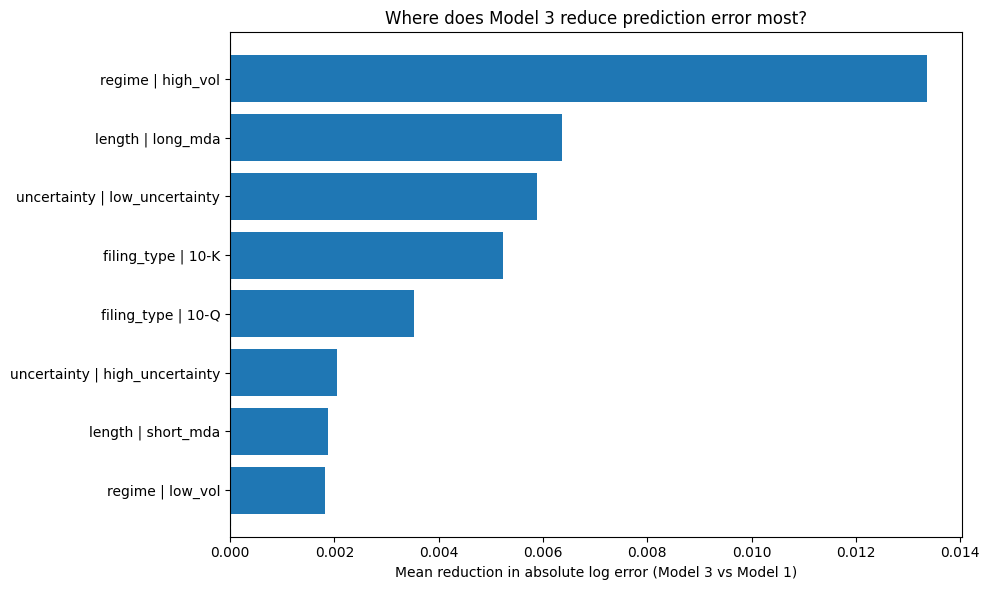

In [46]:
# ============================================================
# Plot average Model 3 gains across key groups
# ============================================================

import matplotlib.pyplot as plt

plot_rows = []

for _, row in error_by_filing_type.iterrows():
    plot_rows.append({
        "group_type": "filing_type",
        "group": row["filing_type"],
        "mean_gain_m3_vs_m1": row["mean_gain_m3_vs_m1"]
    })

for _, row in error_by_regime.iterrows():
    plot_rows.append({
        "group_type": "regime",
        "group": row["regime"],
        "mean_gain_m3_vs_m1": row["mean_gain_m3_vs_m1"]
    })

for _, row in error_by_length.iterrows():
    plot_rows.append({
        "group_type": "length",
        "group": row["length_group"],
        "mean_gain_m3_vs_m1": row["mean_gain_m3_vs_m1"]
    })

for _, row in error_by_uncertainty.iterrows():
    plot_rows.append({
        "group_type": "uncertainty",
        "group": row["uncertainty_group"],
        "mean_gain_m3_vs_m1": row["mean_gain_m3_vs_m1"]
    })

plot_df = pd.DataFrame(plot_rows)
plot_df["label"] = plot_df["group_type"] + " | " + plot_df["group"]
plot_df = plot_df.sort_values("mean_gain_m3_vs_m1", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["mean_gain_m3_vs_m1"])
plt.axvline(0, linestyle="--")
plt.xlabel("Mean reduction in absolute log error (Model 3 vs Model 1)")
plt.ylabel("")
plt.title("Where does Model 3 reduce prediction error most?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# Save outputs
# ============================================================

error_summary.to_csv(f"{OUT_DIR}/error_summary.csv", index=False)

worst_m3_cases[worst_cols_to_show].head(20).to_csv(
    f"{OUT_DIR}/worst_m3_cases_top20.csv", index=False
)

best_m3_improvements[m3_improve_cols_to_show].head(20).to_csv(
    f"{OUT_DIR}/best_m3_improvements_top20.csv", index=False
)

best_m4_improvements[m4_improve_cols_to_show].head(20).to_csv(
    f"{OUT_DIR}/best_m4_improvements_top20.csv", index=False
)

hard_case_summary.to_csv(f"{OUT_DIR}/hard_case_summary.csv", index=False)
error_by_filing_type.to_csv(f"{OUT_DIR}/error_by_filing_type.csv", index=False)
error_by_regime.to_csv(f"{OUT_DIR}/error_by_regime.csv", index=False)
error_by_length.to_csv(f"{OUT_DIR}/error_by_length.csv", index=False)
error_by_uncertainty.to_csv(f"{OUT_DIR}/error_by_uncertainty.csv", index=False)

print("Saved error-analysis outputs.")

Saved error-analysis outputs.


In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/error_summary.csv")
files.download(f"{OUT_DIR}/worst_m3_cases_top20.csv")
files.download(f"{OUT_DIR}/best_m3_improvements_top20.csv")
files.download(f"{OUT_DIR}/best_m4_improvements_top20.csv")
files.download(f"{OUT_DIR}/hard_case_summary.csv")
files.download(f"{OUT_DIR}/error_by_filing_type.csv")
files.download(f"{OUT_DIR}/error_by_regime.csv")
files.download(f"{OUT_DIR}/error_by_length.csv")
files.download(f"{OUT_DIR}/error_by_uncertainty.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# ============================================================
# Final master results table for dissertation
# Uses final_results_df from the gold-methodology notebook
# ============================================================

master_results = final_results_df.copy()

# readable model labels
model_label_map = {
    "NaiveMean": "Naive Mean",
    "NaiveLagVol20d": "Naive Lag Vol (20d)",
    "LinearRegression": "Linear Regression",
    "ElasticNet": "Elastic Net",
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost"
}

# readable dataset/specification labels
dataset_label_map = {
    "naive_mean": "Benchmark",
    "naive_lag_vol20d": "Benchmark",
    "model1_price_only": "Model 1: Price/Context",
    "model2_price_lm": "Model 2: Price/Context + LM",
    "model3_price_lm_finbert": "Model 3: Price/Context + LM + FinBERT PCA",
    "model4_price_lm_finbert_surprise": "Model 4: Model 3 + Surprise"
}

master_results["model_label"] = master_results["model"].map(model_label_map)
master_results["dataset_label"] = master_results["dataset"].map(dataset_label_map)

# ordering
model_order_map = {
    "NaiveMean": 1,
    "NaiveLagVol20d": 2,
    "LinearRegression": 3,
    "ElasticNet": 4,
    "RandomForest": 5,
    "XGBoost": 6
}

dataset_order_map = {
    "naive_mean": 1,
    "naive_lag_vol20d": 2,
    "model1_price_only": 3,
    "model2_price_lm": 4,
    "model3_price_lm_finbert": 5,
    "model4_price_lm_finbert_surprise": 6
}

master_results["model_order"] = master_results["model"].map(model_order_map)
master_results["dataset_order"] = master_results["dataset"].map(dataset_order_map)

# final polished table
master_results_table = master_results[
    [
        "dataset_label",
        "model_label",
        "RMSE_log",
        "MAE_log",
        "R2_log",
        "RMSE",
        "MAE",
        "R2"
    ]
].copy()

master_results_table["model_order"] = master_results["model_order"].values
master_results_table["dataset_order"] = master_results["dataset_order"].values

master_results_table = master_results_table.sort_values(
    ["dataset_order", "model_order"]
).reset_index(drop=True)

master_results_table = master_results_table.drop(columns=["dataset_order", "model_order"])

# round for dissertation display
metric_cols = ["RMSE_log", "MAE_log", "R2_log", "RMSE", "MAE", "R2"]
master_results_table[metric_cols] = master_results_table[metric_cols].round(6)

master_results_table

,dataset_label,model_label,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2
0,Benchmark,Naive Mean,0.555191,0.451961,-0.291755,0.010143,0.006944,-0.046412
1,Benchmark,Naive Lag Vol (20d),0.500118,0.393605,-0.048191,0.010436,0.006499,-0.107727
2,Model 1: Price/Context,Linear Regression,0.476160,0.377280,0.049833,0.009723,0.005925,0.038424
3,Model 1: Price/Context,Elastic Net,0.474807,0.375712,0.055224,0.009465,0.005848,0.088887
4,Model 1: Price/Context,Random Forest,0.441848,0.349608,0.181838,0.008814,0.005410,0.209822
5,Model 1: Price/Context,XGBoost,0.445007,0.348916,0.170095,0.008951,0.005431,0.185172
6,Model 2: Price/Context + LM,Linear Regression,0.476672,0.375704,0.047786,0.009755,0.005905,0.032118
7,Model 2: Price/Context + LM,Elastic Net,0.473251,0.372879,0.061408,0.009533,0.005812,0.075650
8,Model 2: Price/Context + LM,Random Forest,0.440488,0.348397,0.186867,0.008812,0.005376,0.210301
9,Model 2: Price/Context + LM,XGBoost,0.440378,0.344375,0.187271,0.008896,0.005366,0.195032


In [49]:
# ============================================================
# Save final master results table
# ============================================================

master_results_table.to_csv(f"{OUT_DIR}/final_master_results_table.csv", index=False)
print("Saved:", f"{OUT_DIR}/final_master_results_table.csv")

Saved: data/21_final_gold_methodology/final_master_results_table.csv


In [50]:
# ============================================================
# Optional: main models only table for dissertation body
# Keeps the strongest nonlinear models + benchmarks
# ============================================================

main_models_only = master_results.copy()

keep_rows = (
    ((main_models_only["dataset"].isin(["naive_mean", "naive_lag_vol20d"]))) |
    ((main_models_only["model"] == "RandomForest") & (main_models_only["dataset"].isin([
        "model1_price_only",
        "model2_price_lm",
        "model3_price_lm_finbert",
        "model4_price_lm_finbert_surprise"
    ]))) |
    ((main_models_only["model"] == "XGBoost") & (main_models_only["dataset"].isin([
        "model1_price_only",
        "model2_price_lm",
        "model3_price_lm_finbert",
        "model4_price_lm_finbert_surprise"
    ])))
)

main_models_only = main_models_only.loc[keep_rows].copy()
main_models_only["model_label"] = main_models_only["model"].map(model_label_map)
main_models_only["dataset_label"] = main_models_only["dataset"].map(dataset_label_map)
main_models_only["model_order"] = main_models_only["model"].map(model_order_map)
main_models_only["dataset_order"] = main_models_only["dataset"].map(dataset_order_map)

main_models_table = main_models_only[
    ["dataset_label", "model_label", "RMSE_log", "MAE_log", "R2_log", "RMSE", "MAE", "R2", "dataset_order", "model_order"]
].copy()

main_models_table = main_models_table.sort_values(
    ["dataset_order", "model_order"]
).reset_index(drop=True)

main_models_table = main_models_table.drop(columns=["dataset_order", "model_order"])
main_models_table[metric_cols] = main_models_table[metric_cols].round(6)

main_models_table

,dataset_label,model_label,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2
0,Benchmark,Naive Mean,0.555191,0.451961,-0.291755,0.010143,0.006944,-0.046412
1,Benchmark,Naive Lag Vol (20d),0.500118,0.393605,-0.048191,0.010436,0.006499,-0.107727
2,Model 1: Price/Context,Random Forest,0.441848,0.349608,0.181838,0.008814,0.005410,0.209822
3,Model 1: Price/Context,XGBoost,0.445007,0.348916,0.170095,0.008951,0.005431,0.185172
4,Model 2: Price/Context + LM,Random Forest,0.440488,0.348397,0.186867,0.008812,0.005376,0.210301
5,Model 2: Price/Context + LM,XGBoost,0.440378,0.344375,0.187271,0.008896,0.005366,0.195032
6,Model 3: Price/Context + LM + FinBERT PCA,Random Forest,0.437074,0.345732,0.199421,0.008786,0.005359,0.214823
7,Model 3: Price/Context + LM + FinBERT PCA,XGBoost,0.442560,0.345661,0.179197,0.008826,0.005383,0.207768
8,Model 4: Model 3 + Surprise,Random Forest,0.437697,0.346166,0.197135,0.008765,0.005366,0.218668
9,Model 4: Model 3 + Surprise,XGBoost,0.446646,0.351260,0.163969,0.008848,0.005478,0.203767


In [51]:
# ============================================================
# Save main models only table
# ============================================================

main_models_table.to_csv(f"{OUT_DIR}/main_models_results_table.csv", index=False)
print("Saved:", f"{OUT_DIR}/main_models_results_table.csv")

Saved: data/21_final_gold_methodology/main_models_results_table.csv


In [ ]:
# ============================================================
# Download the saved tables
# ============================================================

from google.colab import files

files.download(f"{OUT_DIR}/final_master_results_table.csv")
files.download(f"{OUT_DIR}/main_models_results_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
import os
import pandas as pd
import numpy as np

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

round1_df = pd.read_csv("round1_improved_baseline_dataset.csv")
round4_light_df = pd.read_csv("round4_light_text_surprise_dataset.csv")

print("Round 1 shape:", round1_df.shape)
print("Round 4 light shape:", round4_light_df.shape)

Round 1 shape: (2181, 41)
Round 4 light shape: (2058, 46)


In [53]:
for df_ in [round1_df, round4_light_df]:
    df_["filing_date"] = pd.to_datetime(df_["filing_date"], errors="coerce")

split_date = pd.Timestamp("2023-01-01")

final_train_rows = (round4_light_df["filing_date"] < split_date).sum()
final_test_rows = (round4_light_df["filing_date"] >= split_date).sum()

print("Final train rows:", final_train_rows)
print("Final test rows:", final_test_rows)

Final train rows: 1272
Final test rows: 786


In [54]:
# ============================================================
# FILLED VALUES FROM YOUR COMPLETED PIPELINE
# ============================================================

initial_firms = 150
valid_firms = 148
filing_events = 2955
successful_mda_events = 2265
price_aligned_observations = 2247
round2_sample = 2058

In [55]:
# ============================================================
# Build attrition table
# ============================================================

rows = [
    {
        "stage": "Initial firms",
        "description": "Initial candidate firm universe",
        "unit": "firms",
        "rows_remaining": initial_firms,
    },
    {
        "stage": "Valid firms",
        "description": "Firms retained after identifier validation and cleaning",
        "unit": "firms",
        "rows_remaining": valid_firms,
    },
    {
        "stage": "Filing events",
        "description": "10-K / 10-Q filing events collected",
        "unit": "events",
        "rows_remaining": filing_events,
    },
    {
        "stage": "Successful MD&A events",
        "description": "Filing events with usable MD&A extracted",
        "unit": "events",
        "rows_remaining": successful_mda_events,
    },
    {
        "stage": "Price-aligned observations",
        "description": "MD&A events successfully aligned to price data",
        "unit": "observations",
        "rows_remaining": price_aligned_observations,
    },
    {
        "stage": "Round 1 sample",
        "description": "Improved baseline modelling sample",
        "unit": "observations",
        "rows_remaining": len(round1_df),
    },
    {
        "stage": "Round 2 sample",
        "description": "Round 2 modelling sample",
        "unit": "observations",
        "rows_remaining": round2_sample,
    },
    {
        "stage": "Round 4 light sample",
        "description": "Light semantic-surprise modelling sample",
        "unit": "observations",
        "rows_remaining": len(round4_light_df),
    },
    {
        "stage": "Final train sample",
        "description": "Pre-2023 training sample in final gold-standard notebook",
        "unit": "observations",
        "rows_remaining": int(final_train_rows),
    },
    {
        "stage": "Final test sample",
        "description": "2023–2024 untouched holdout sample",
        "unit": "observations",
        "rows_remaining": int(final_test_rows),
    },
]

attrition_df = pd.DataFrame(rows)
attrition_df["rows_remaining"] = pd.to_numeric(attrition_df["rows_remaining"], errors="coerce")

# Only compute loss/retention when the unit stays the same
attrition_df["prev_rows"] = attrition_df["rows_remaining"].shift(1)
attrition_df["prev_unit"] = attrition_df["unit"].shift(1)

same_unit = attrition_df["unit"] == attrition_df["prev_unit"]

attrition_df["rows_lost_from_previous"] = np.where(
    same_unit,
    attrition_df["prev_rows"] - attrition_df["rows_remaining"],
    np.nan
)

attrition_df["retention_pct_from_previous"] = np.where(
    same_unit,
    (attrition_df["rows_remaining"] / attrition_df["prev_rows"]) * 100,
    np.nan
)

attrition_df = attrition_df.drop(columns=["prev_rows", "prev_unit"])

attrition_df

,stage,description,unit,rows_remaining,rows_lost_from_previous,retention_pct_from_previous
0,Initial firms,Initial candidate firm universe,firms,150,NaN,NaN
1,Valid firms,Firms retained after identifier validation and...,firms,148,2.0,98.666667
2,Filing events,10-K / 10-Q filing events collected,events,2955,NaN,NaN
3,Successful MD&A events,Filing events with usable MD&A extracted,events,2265,690.0,76.649746
4,Price-aligned observations,MD&A events successfully aligned to price data,observations,2247,NaN,NaN
5,Round 1 sample,Improved baseline modelling sample,observations,2181,66.0,97.062750
6,Round 2 sample,Round 2 modelling sample,observations,2058,123.0,94.360385
7,Round 4 light sample,Light semantic-surprise modelling sample,observations,2058,0.0,100.000000
8,Final train sample,Pre-2023 training sample in final gold-standar...,observations,1272,786.0,61.807580
9,Final test sample,2023–2024 untouched holdout sample,observations,786,486.0,61.792453


In [56]:
# Blank out non-comparable transitions / non-attrition rows
blank_loss_rows = [
    "Filing events",
    "Price-aligned observations",
    "Final train sample",
    "Final test sample"
]

mask = attrition_df["stage"].isin(blank_loss_rows)
attrition_df.loc[mask, "rows_lost_from_previous"] = np.nan
attrition_df.loc[mask, "retention_pct_from_previous"] = np.nan

attrition_display = attrition_df.copy()
attrition_display["rows_remaining"] = attrition_display["rows_remaining"].round(0)
attrition_display["rows_lost_from_previous"] = attrition_display["rows_lost_from_previous"].round(0)
attrition_display["retention_pct_from_previous"] = attrition_display["retention_pct_from_previous"].round(2)

attrition_display

,stage,description,unit,rows_remaining,rows_lost_from_previous,retention_pct_from_previous
0,Initial firms,Initial candidate firm universe,firms,150,NaN,NaN
1,Valid firms,Firms retained after identifier validation and...,firms,148,2.0,98.67
2,Filing events,10-K / 10-Q filing events collected,events,2955,NaN,NaN
3,Successful MD&A events,Filing events with usable MD&A extracted,events,2265,690.0,76.65
4,Price-aligned observations,MD&A events successfully aligned to price data,observations,2247,NaN,NaN
5,Round 1 sample,Improved baseline modelling sample,observations,2181,66.0,97.06
6,Round 2 sample,Round 2 modelling sample,observations,2058,123.0,94.36
7,Round 4 light sample,Light semantic-surprise modelling sample,observations,2058,0.0,100.00
8,Final train sample,Pre-2023 training sample in final gold-standar...,observations,1272,NaN,NaN
9,Final test sample,2023–2024 untouched holdout sample,observations,786,NaN,NaN


In [57]:
attrition_df.to_csv(f"{OUT_DIR}/sample_attrition_table_full.csv", index=False)
attrition_display.to_csv(f"{OUT_DIR}/sample_attrition_table_display.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/sample_attrition_table_full.csv")
print(f"{OUT_DIR}/sample_attrition_table_display.csv")

Saved:
data/21_final_gold_methodology/sample_attrition_table_full.csv
data/21_final_gold_methodology/sample_attrition_table_display.csv


In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/sample_attrition_table_full.csv")
files.download(f"{OUT_DIR}/sample_attrition_table_display.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
# ============================================================
# Minimal Diebold–Mariano-style forecast comparison
# Uses final holdout predictions from your gold-methodology notebook
# Compares key RandomForest model pairs on the log target
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

# ------------------------------------------------------------
# 1) Build holdout predictions for key RandomForest models
# ------------------------------------------------------------

dm_df = test_final.copy()

rf_m1 = saved_final_models[("RandomForest", "model1_price_only")]
rf_m2 = saved_final_models[("RandomForest", "model2_price_lm")]
rf_m3 = saved_final_models[("RandomForest", "model3_price_lm_finbert")]
rf_m4 = saved_final_models[("RandomForest", "model4_price_lm_finbert_surprise")]

dm_df["y_true_log"] = dm_df[TARGET_LOG].astype(float)

dm_df["pred_m1_log"] = rf_m1.predict(dm_df[get_feature_columns("model1_price_only")])
dm_df["pred_m2_log"] = rf_m2.predict(dm_df[get_feature_columns("model2_price_lm")])
dm_df["pred_m3_log"] = rf_m3.predict(dm_df[get_feature_columns("model3_price_lm_finbert")])
dm_df["pred_m4_log"] = rf_m4.predict(dm_df[get_feature_columns("model4_price_lm_finbert_surprise")])

print("DM dataframe shape:", dm_df.shape)

# ------------------------------------------------------------
# 2) Simple Diebold–Mariano-style test function
#    Loss differential d_t = L1_t - L2_t
#    Positive mean(d) => model 2 has lower average loss
#
#    This version supports:
#    - squared error loss
#    - absolute error loss
#    - optional HAC/Newey-West variance adjustment
#
#    horizon = 1 is appropriate here because each filing row is
#    one forecast target observation in the final holdout sample.
# ------------------------------------------------------------

def _autocovariance(x, lag):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    if lag >= n:
        return 0.0
    return np.sum(x[lag:] * x[:n-lag]) / n

def dm_test(loss_1, loss_2, h=1, use_hac=True):
    """
    Minimal Diebold-Mariano-style test.

    Parameters
    ----------
    loss_1 : array-like
        Losses from reference model.
    loss_2 : array-like
        Losses from comparison model.
    h : int
        Forecast horizon. Use h=1 here.
    use_hac : bool
        If True, use HAC variance estimate with truncation h-1.
        With h=1 this becomes the usual variance estimate.

    Returns
    -------
    dict
    """
    loss_1 = np.asarray(loss_1, dtype=float)
    loss_2 = np.asarray(loss_2, dtype=float)

    if len(loss_1) != len(loss_2):
        raise ValueError("loss_1 and loss_2 must have same length.")

    d = loss_1 - loss_2
    T = len(d)
    d_bar = np.mean(d)

    # HAC / Newey-West style long-run variance estimate
    gamma0 = _autocovariance(d, 0)

    if use_hac and h > 1:
        lrv = gamma0
        for lag in range(1, h):
            weight = 1 - lag / h
            gamma = _autocovariance(d, lag)
            lrv += 2 * weight * gamma
    else:
        lrv = gamma0

    if lrv <= 0:
        dm_stat = np.nan
        p_value = np.nan
    else:
        dm_stat = d_bar / np.sqrt(lrv / T)
        p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return {
        "n_obs": T,
        "mean_loss_model_1": float(np.mean(loss_1)),
        "mean_loss_model_2": float(np.mean(loss_2)),
        "mean_loss_diff_m1_minus_m2": float(d_bar),
        "dm_stat": float(dm_stat) if np.isfinite(dm_stat) else np.nan,
        "p_value_two_sided": float(p_value) if np.isfinite(p_value) else np.nan
    }

# ------------------------------------------------------------
# 3) Helper to compare two prediction columns
# ------------------------------------------------------------

def run_dm_pair(df, pred_col_1, pred_col_2, model_name_1, model_name_2):
    y = df["y_true_log"].to_numpy()

    e1 = y - df[pred_col_1].to_numpy()
    e2 = y - df[pred_col_2].to_numpy()

    sq_loss_1 = e1 ** 2
    sq_loss_2 = e2 ** 2

    abs_loss_1 = np.abs(e1)
    abs_loss_2 = np.abs(e2)

    sq_res = dm_test(sq_loss_1, sq_loss_2, h=1, use_hac=True)
    abs_res = dm_test(abs_loss_1, abs_loss_2, h=1, use_hac=True)

    return [
        {
            "comparison": f"{model_name_1} vs {model_name_2}",
            "loss_type": "squared_error",
            "better_model_if_diff_positive": model_name_2,
            **sq_res
        },
        {
            "comparison": f"{model_name_1} vs {model_name_2}",
            "loss_type": "absolute_error",
            "better_model_if_diff_positive": model_name_2,
            **abs_res
        }
    ]

# ------------------------------------------------------------
# 4) Run the key forecast comparisons
#    Keep this small and focused
# ------------------------------------------------------------

dm_rows = []

# Main final text-rich model vs financial baseline
dm_rows += run_dm_pair(
    dm_df,
    pred_col_1="pred_m1_log",
    pred_col_2="pred_m3_log",
    model_name_1="RF Model 1",
    model_name_2="RF Model 3"
)

# FinBERT beyond LM
dm_rows += run_dm_pair(
    dm_df,
    pred_col_1="pred_m2_log",
    pred_col_2="pred_m3_log",
    model_name_1="RF Model 2",
    model_name_2="RF Model 3"
)

# Surprise extension beyond final main model
dm_rows += run_dm_pair(
    dm_df,
    pred_col_1="pred_m3_log",
    pred_col_2="pred_m4_log",
    model_name_1="RF Model 3",
    model_name_2="RF Model 4"
)

dm_results = pd.DataFrame(dm_rows)

# nicer rounding
round_cols = [
    "mean_loss_model_1",
    "mean_loss_model_2",
    "mean_loss_diff_m1_minus_m2",
    "dm_stat",
    "p_value_two_sided"
]
dm_results[round_cols] = dm_results[round_cols].round(6)

dm_results

DM dataframe shape: (786, 98)


,comparison,loss_type,better_model_if_diff_positive,n_obs,mean_loss_model_1,mean_loss_model_2,mean_loss_diff_m1_minus_m2,dm_stat,p_value_two_sided
0,RF Model 1 vs RF Model 3,squared_error,RF Model 3,786,0.195229,0.191034,0.004196,2.120372,0.033975
1,RF Model 1 vs RF Model 3,absolute_error,RF Model 3,786,0.349608,0.345732,0.003876,1.826916,0.067712
2,RF Model 2 vs RF Model 3,squared_error,RF Model 3,786,0.194029,0.191034,0.002996,1.652681,0.098396
3,RF Model 2 vs RF Model 3,absolute_error,RF Model 3,786,0.348397,0.345732,0.002665,1.353662,0.175844
4,RF Model 3 vs RF Model 4,squared_error,RF Model 4,786,0.191034,0.191579,-0.000545,-0.534395,0.593068
5,RF Model 3 vs RF Model 4,absolute_error,RF Model 4,786,0.345732,0.346166,-0.000434,-0.386729,0.698957


In [59]:
# ============================================================
# 5) Simple significance labels for easier reading
# ============================================================

dm_results_display = dm_results.copy()

def sig_label(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

dm_results_display["sig"] = dm_results_display["p_value_two_sided"].apply(sig_label)

dm_results_display

,comparison,loss_type,better_model_if_diff_positive,n_obs,mean_loss_model_1,mean_loss_model_2,mean_loss_diff_m1_minus_m2,dm_stat,p_value_two_sided,sig
0,RF Model 1 vs RF Model 3,squared_error,RF Model 3,786,0.195229,0.191034,0.004196,2.120372,0.033975,**
1,RF Model 1 vs RF Model 3,absolute_error,RF Model 3,786,0.349608,0.345732,0.003876,1.826916,0.067712,*
2,RF Model 2 vs RF Model 3,squared_error,RF Model 3,786,0.194029,0.191034,0.002996,1.652681,0.098396,*
3,RF Model 2 vs RF Model 3,absolute_error,RF Model 3,786,0.348397,0.345732,0.002665,1.353662,0.175844,
4,RF Model 3 vs RF Model 4,squared_error,RF Model 4,786,0.191034,0.191579,-0.000545,-0.534395,0.593068,
5,RF Model 3 vs RF Model 4,absolute_error,RF Model 4,786,0.345732,0.346166,-0.000434,-0.386729,0.698957,


In [60]:
# ============================================================
# 6) Save results
# ============================================================

dm_results.to_csv(f"{OUT_DIR}/dm_test_results.csv", index=False)
dm_results_display.to_csv(f"{OUT_DIR}/dm_test_results_display.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/dm_test_results.csv")
print(f"{OUT_DIR}/dm_test_results_display.csv")

Saved:
data/21_final_gold_methodology/dm_test_results.csv
data/21_final_gold_methodology/dm_test_results_display.csv


In [ ]:
# ============================================================
# 7) Download results
# ============================================================

from google.colab import files

files.download(f"{OUT_DIR}/dm_test_results.csv")
files.download(f"{OUT_DIR}/dm_test_results_display.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

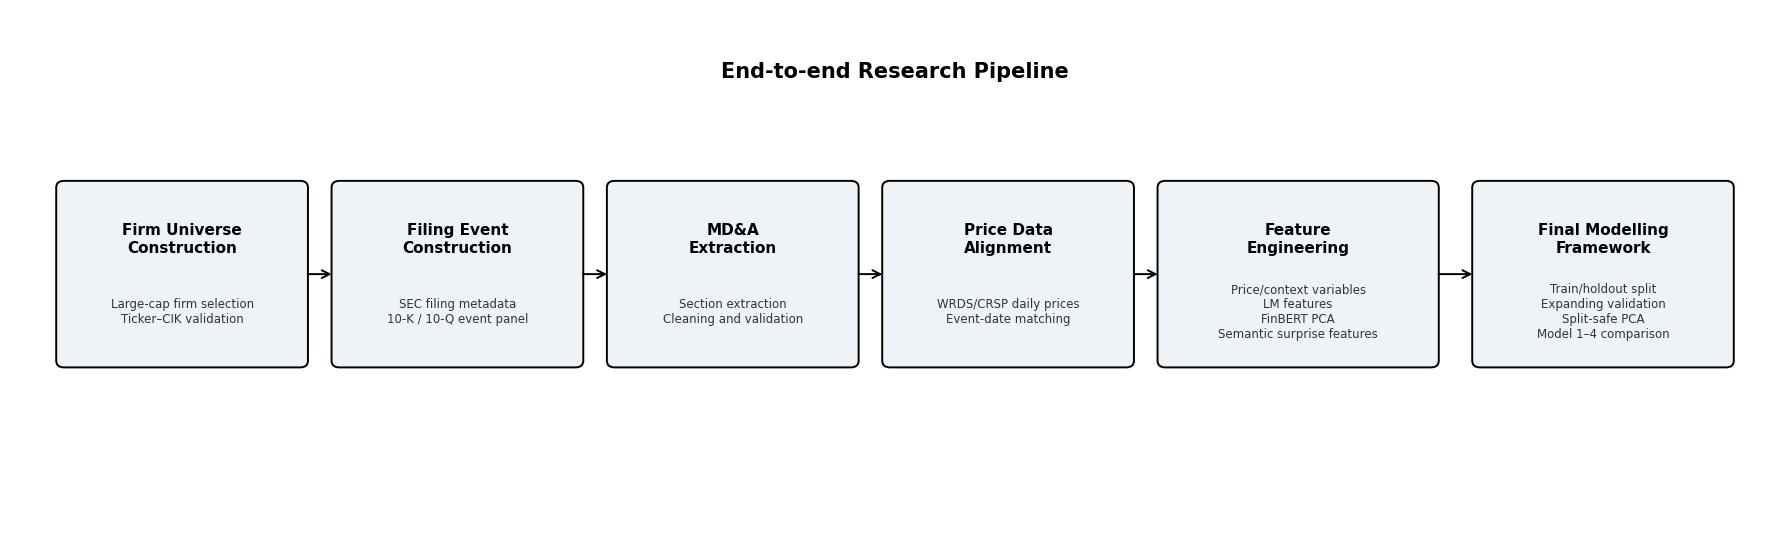

Saved as pipeline_diagram.png


In [61]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 5.5))
ax.set_xlim(0, 18)
ax.set_ylim(0, 6.3)
ax.axis("off")

boxes = [
    {
        "x": 0.5, "y": 2.0, "w": 2.5, "h": 2.2,
        "title": "Firm Universe\nConstruction",
        "subtitle": "Large-cap firm selection\nTicker–CIK validation"
    },
    {
        "x": 3.3, "y": 2.0, "w": 2.5, "h": 2.2,
        "title": "Filing Event\nConstruction",
        "subtitle": "SEC filing metadata\n10-K / 10-Q event panel"
    },
    {
        "x": 6.1, "y": 2.0, "w": 2.5, "h": 2.2,
        "title": "MD&A\nExtraction",
        "subtitle": "Section extraction\nCleaning and validation"
    },
    {
        "x": 8.9, "y": 2.0, "w": 2.5, "h": 2.2,
        "title": "Price Data\nAlignment",
        "subtitle": "WRDS/CRSP daily prices\nEvent-date matching"
    },
    {
        "x": 11.7, "y": 2.0, "w": 2.8, "h": 2.2,
        "title": "Feature\nEngineering",
        "subtitle": "Price/context variables\nLM features\nFinBERT PCA\nSemantic surprise features"
    },
    {
        "x": 14.9, "y": 2.0, "w": 2.6, "h": 2.2,
        "title": "Final Modelling\nFramework",
        "subtitle": "Train/holdout split\nExpanding validation\nSplit-safe PCA\nModel 1–4 comparison"
    }
]

for box in boxes:
    patch = FancyBboxPatch(
        (box["x"], box["y"]),
        box["w"],
        box["h"],
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.4,
        edgecolor="black",
        facecolor="#EEF3F7"
    )
    ax.add_patch(patch)

    ax.text(
        box["x"] + box["w"] / 2,
        box["y"] + box["h"] * 0.69,
        box["title"],
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        box["x"] + box["w"] / 2,
        box["y"] + box["h"] * 0.29,
        box["subtitle"],
        ha="center",
        va="center",
        fontsize=8.5,
        color="#333333"
    )

for i in range(len(boxes) - 1):
    x1 = boxes[i]["x"] + boxes[i]["w"]
    y1 = boxes[i]["y"] + boxes[i]["h"] / 2
    x2 = boxes[i + 1]["x"]
    y2 = boxes[i + 1]["y"] + boxes[i + 1]["h"] / 2

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=14,
        linewidth=1.4,
        color="black"
    )
    ax.add_patch(arrow)

ax.text(
    9, 5.55,
    "End-to-end Research Pipeline",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("pipeline_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as pipeline_diagram.png")

In [ ]:
from google.colab import files
files.download("pipeline_diagram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2nd visulisation

In [62]:
import pandas as pd
import numpy as np

# ============================================================
# Locked final counts
# ============================================================

attrition_rows = [
    {
        "stage": "Initial firms",
        "description": "Initial candidate firm universe",
        "unit": "firms",
        "rows_remaining": 150,
        "comparable_to_previous": False
    },
    {
        "stage": "Valid firms",
        "description": "Firms retained after validation and cleaning",
        "unit": "firms",
        "rows_remaining": 148,
        "comparable_to_previous": True
    },
    {
        "stage": "Filing events",
        "description": "10-K / 10-Q filing events collected",
        "unit": "events",
        "rows_remaining": 2955,
        "comparable_to_previous": False
    },
    {
        "stage": "Usable MD&A events",
        "description": "Filing events with usable MD&A extracted",
        "unit": "events",
        "rows_remaining": 2265,
        "comparable_to_previous": True
    },
    {
        "stage": "Price-aligned observations",
        "description": "MD&A events aligned to price data",
        "unit": "observations",
        "rows_remaining": 2247,
        "comparable_to_previous": False
    },
    {
        "stage": "Round 1 sample",
        "description": "Improved baseline modelling sample",
        "unit": "observations",
        "rows_remaining": 2181,
        "comparable_to_previous": True
    },
    {
        "stage": "Round 2 sample",
        "description": "Text-change modelling sample",
        "unit": "observations",
        "rows_remaining": 2058,
        "comparable_to_previous": True
    },
    {
        "stage": "Round 4 light sample",
        "description": "Light semantic-surprise modelling sample",
        "unit": "observations",
        "rows_remaining": 2058,
        "comparable_to_previous": True
    },
    {
        "stage": "Final train sample",
        "description": "Pre-2023 training sample",
        "unit": "observations",
        "rows_remaining": 1272,
        "comparable_to_previous": False
    },
    {
        "stage": "Final holdout sample",
        "description": "2023–2024 untouched holdout sample",
        "unit": "observations",
        "rows_remaining": 786,
        "comparable_to_previous": False
    }
]

attrition_df = pd.DataFrame(attrition_rows)

# compute attrition only where comparison is valid
attrition_df["rows_lost_from_previous"] = np.nan
attrition_df["retention_pct_from_previous"] = np.nan

for i in range(1, len(attrition_df)):
    if attrition_df.loc[i, "comparable_to_previous"]:
        prev_val = attrition_df.loc[i - 1, "rows_remaining"]
        curr_val = attrition_df.loc[i, "rows_remaining"]

        attrition_df.loc[i, "rows_lost_from_previous"] = prev_val - curr_val
        attrition_df.loc[i, "retention_pct_from_previous"] = (curr_val / prev_val) * 100

attrition_df

,stage,description,unit,rows_remaining,comparable_to_previous,rows_lost_from_previous,retention_pct_from_previous
0,Initial firms,Initial candidate firm universe,firms,150,False,NaN,NaN
1,Valid firms,Firms retained after validation and cleaning,firms,148,True,2.0,98.666667
2,Filing events,10-K / 10-Q filing events collected,events,2955,False,NaN,NaN
3,Usable MD&A events,Filing events with usable MD&A extracted,events,2265,True,690.0,76.649746
4,Price-aligned observations,MD&A events aligned to price data,observations,2247,False,NaN,NaN
5,Round 1 sample,Improved baseline modelling sample,observations,2181,True,66.0,97.062750
6,Round 2 sample,Text-change modelling sample,observations,2058,True,123.0,94.360385
7,Round 4 light sample,Light semantic-surprise modelling sample,observations,2058,True,0.0,100.000000
8,Final train sample,Pre-2023 training sample,observations,1272,False,NaN,NaN
9,Final holdout sample,2023–2024 untouched holdout sample,observations,786,False,NaN,NaN


In [63]:
attrition_display = attrition_df.copy()

attrition_display["rows_remaining"] = attrition_display["rows_remaining"].astype(int)

attrition_display["rows_lost_from_previous"] = (
    attrition_display["rows_lost_from_previous"]
    .round(0)
)

attrition_display["retention_pct_from_previous"] = (
    attrition_display["retention_pct_from_previous"]
    .round(2)
)

# drop helper column and replace NaN with blanks for clean display
attrition_display = attrition_display.drop(columns=["comparable_to_previous"])
attrition_display = attrition_display.fillna("")

attrition_display

,stage,description,unit,rows_remaining,rows_lost_from_previous,retention_pct_from_previous
0,Initial firms,Initial candidate firm universe,firms,150,,
1,Valid firms,Firms retained after validation and cleaning,firms,148,2.0,98.67
2,Filing events,10-K / 10-Q filing events collected,events,2955,,
3,Usable MD&A events,Filing events with usable MD&A extracted,events,2265,690.0,76.65
4,Price-aligned observations,MD&A events aligned to price data,observations,2247,,
5,Round 1 sample,Improved baseline modelling sample,observations,2181,66.0,97.06
6,Round 2 sample,Text-change modelling sample,observations,2058,123.0,94.36
7,Round 4 light sample,Light semantic-surprise modelling sample,observations,2058,0.0,100.0
8,Final train sample,Pre-2023 training sample,observations,1272,,
9,Final holdout sample,2023–2024 untouched holdout sample,observations,786,,


In [64]:
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

attrition_df.to_csv(f"{OUT_DIR}/sample_attrition_table_full_clean.csv", index=False)
attrition_display.to_csv(f"{OUT_DIR}/sample_attrition_table_display_clean.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/sample_attrition_table_full_clean.csv")
print(f"{OUT_DIR}/sample_attrition_table_display_clean.csv")

Saved:
data/21_final_gold_methodology/sample_attrition_table_full_clean.csv
data/21_final_gold_methodology/sample_attrition_table_display_clean.csv


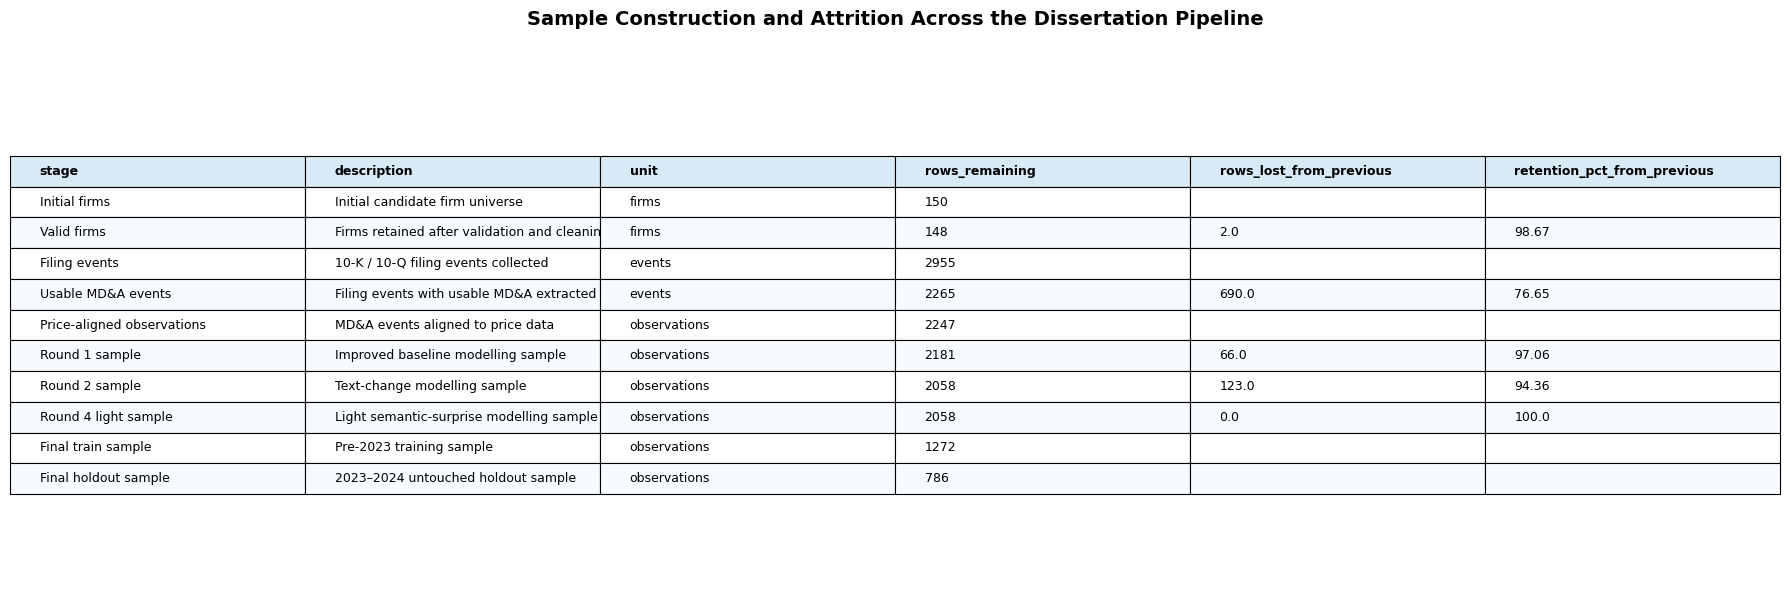

Saved as sample_attrition_table.png


In [65]:
import matplotlib.pyplot as plt

render_df = attrition_display.copy()

fig, ax = plt.subplots(figsize=(18, 6.2))
ax.axis("off")

table = ax.table(
    cellText=render_df.values,
    colLabels=render_df.columns,
    loc="center",
    cellLoc="left",
    colLoc="left"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# style cells
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAF7")
    else:
        if row % 2 == 0:
            cell.set_facecolor("#F7FBFF")
        else:
            cell.set_facecolor("white")

# optional: center the numeric columns
numeric_cols = [3, 4, 5]  # rows_remaining, rows_lost_from_previous, retention_pct_from_previous
for (row, col), cell in table.get_celld().items():
    if row > 0 and col in numeric_cols:
        cell._loc = "center"

plt.title(
    "Sample Construction and Attrition Across the Dissertation Pipeline",
    fontsize=14,
    fontweight="bold",
    pad=18
)

plt.tight_layout()
plt.savefig("sample_attrition_table.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as sample_attrition_table.png")

In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/sample_attrition_table_full_clean.csv")
files.download(f"{OUT_DIR}/sample_attrition_table_display_clean.csv")
files.download("sample_attrition_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3rd visulisation

       future_realized_vol_10d  log_future_realized_vol_10d
count              2058.000000                  2058.000000
mean                  0.018219                    -4.155820
std                   0.011479                     0.532884
min                   0.003724                    -5.593002
25%                   0.010685                    -4.538902
50%                   0.015183                    -4.187555
75%                   0.021985                    -3.817414
max                   0.147441                    -1.914324


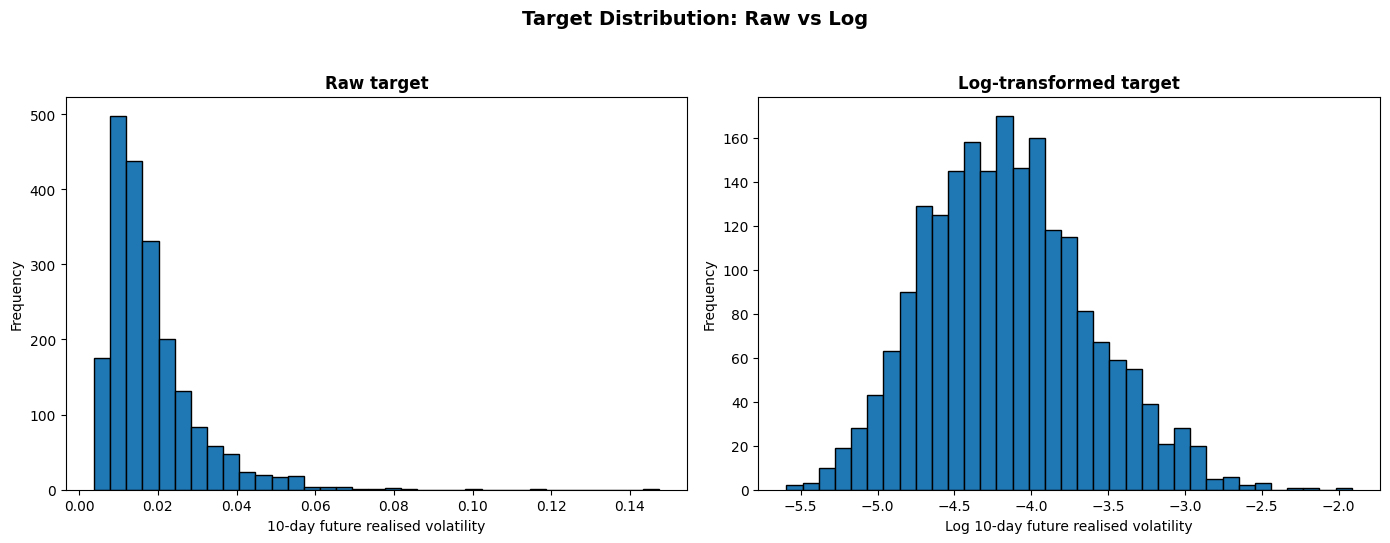

Saved as target_distribution_raw_vs_log.png


In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df = pd.read_csv("round4_light_text_surprise_dataset.csv")

target_raw = "future_realized_vol_10d"
target_log = "log_future_realized_vol_10d"

# Keep only valid rows
df = df[df[target_raw].notna()].copy()
df = df[df[target_raw] > 0].copy()

if target_log not in df.columns:
    df[target_log] = np.log(df[target_raw])

# ------------------------------------------------------------
# Optional: check summary stats separately (not part of figure)
# ------------------------------------------------------------
summary_stats = df[[target_raw, target_log]].describe()
print(summary_stats)

# ------------------------------------------------------------
# Plot raw vs log target distributions
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Raw target
axes[0].hist(df[target_raw], bins=35, edgecolor="black")
axes[0].set_title("Raw target", fontweight="bold", fontsize=12)
axes[0].set_xlabel("10-day future realised volatility")
axes[0].set_ylabel("Frequency")

# Log target
axes[1].hist(df[target_log], bins=35, edgecolor="black")
axes[1].set_title("Log-transformed target", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Log 10-day future realised volatility")
axes[1].set_ylabel("Frequency")

# Main title (do not include figure number)
fig.suptitle("Target Distribution: Raw vs Log", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("target_distribution_raw_vs_log.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as target_distribution_raw_vs_log.png")

In [ ]:
# ============================================================
# Download the figure
# ============================================================

from google.colab import files
files.download("target_distribution_raw_vs_log.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

4th visulisation

filing_type  10-K  10-Q
filing_year            
2019           12   144
2020           66   274
2021           76   304
2022           76   320
2023           83   315
2024           81   307


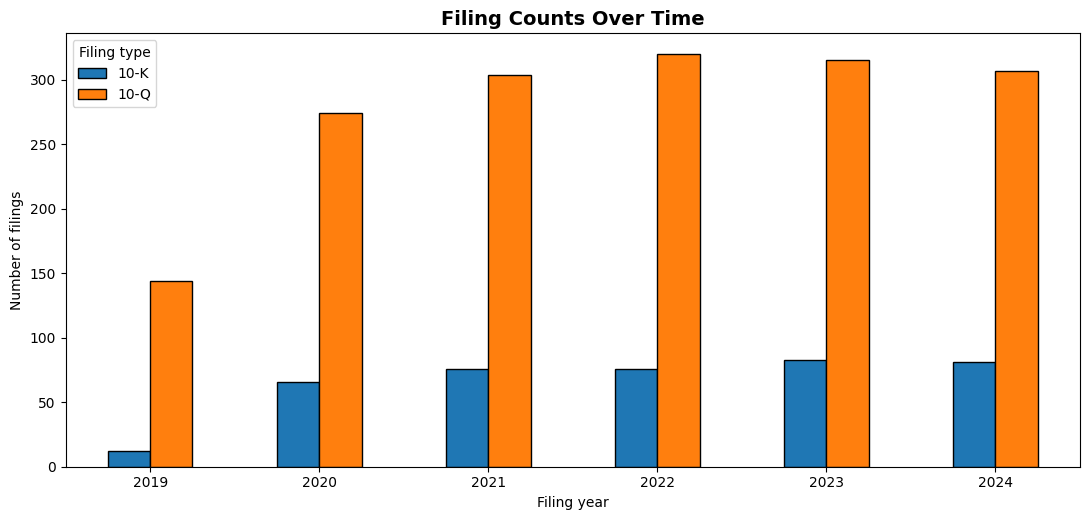

Saved as filing_counts_over_time.png


In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df = pd.read_csv("round4_light_text_surprise_dataset.csv")

# Basic cleaning
df["filing_date"] = pd.to_datetime(df["filing_date"], errors="coerce")
df["filing_type"] = df["filing_type"].astype(str).str.strip().str.upper()

df = df[df["filing_date"].notna()].copy()
df["filing_year"] = df["filing_date"].dt.year

# Keep only 10-K / 10-Q
df = df[df["filing_type"].isin(["10-K", "10-Q"])].copy()

# ------------------------------------------------------------
# Build yearly counts
# ------------------------------------------------------------
year_counts = (
    df.groupby(["filing_year", "filing_type"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

for col in ["10-K", "10-Q"]:
    if col not in year_counts.columns:
        year_counts[col] = 0

year_counts = year_counts[["10-K", "10-Q"]]

# Optional: check counts separately (not part of final figure)
print(year_counts)

# ------------------------------------------------------------
# Plot filing counts over time
# ------------------------------------------------------------
ax = year_counts.plot(
    kind="bar",
    figsize=(11, 5.3),
    edgecolor="black"
)

ax.set_title("Filing Counts Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Filing year")
ax.set_ylabel("Number of filings")
ax.legend(title="Filing type", frameon=True)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("filing_counts_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as filing_counts_over_time.png")

In [ ]:
# ============================================================
# Download the figure
# ============================================================

from google.colab import files
files.download("filing_counts_over_time.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5th visulisation

In [68]:
# ============================================================
# Visualization 5: Final modelling dataset summary table
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df = pd.read_csv("round4_light_text_surprise_dataset.csv")

# Basic cleaning
df["filing_date"] = pd.to_datetime(df["filing_date"], errors="coerce")
df["filing_type"] = df["filing_type"].astype(str).str.strip().str.upper()
df["ticker"] = df["ticker"].astype(str).str.strip().str.upper()

df = df[df["filing_date"].notna()].copy()

# ------------------------------------------------------------
# Build summary values
# ------------------------------------------------------------
split_date = pd.Timestamp("2023-01-01")

n_firms = df["ticker"].nunique()
n_obs = len(df)
n_10k = (df["filing_type"] == "10-K").sum()
n_10q = (df["filing_type"] == "10-Q").sum()
date_min = df["filing_date"].min().date()
date_max = df["filing_date"].max().date()
final_train = (df["filing_date"] < split_date).sum()
final_holdout = (df["filing_date"] >= split_date).sum()

summary_table = pd.DataFrame({
    "Metric": [
        "Unique firms",
        "Final modelling observations",
        "10-K observations",
        "10-Q observations",
        "Study start date",
        "Study end date",
        "Final training observations",
        "Final holdout observations"
    ],
    "Value": [
        n_firms,
        n_obs,
        n_10k,
        n_10q,
        str(date_min),
        str(date_max),
        final_train,
        final_holdout
    ]
})

summary_table

,Metric,Value
0,Unique firms,122
1,Final modelling observations,2058
2,10-K observations,394
3,10-Q observations,1664
4,Study start date,2019-05-31
5,Study end date,2024-12-13
6,Final training observations,1272
7,Final holdout observations,786


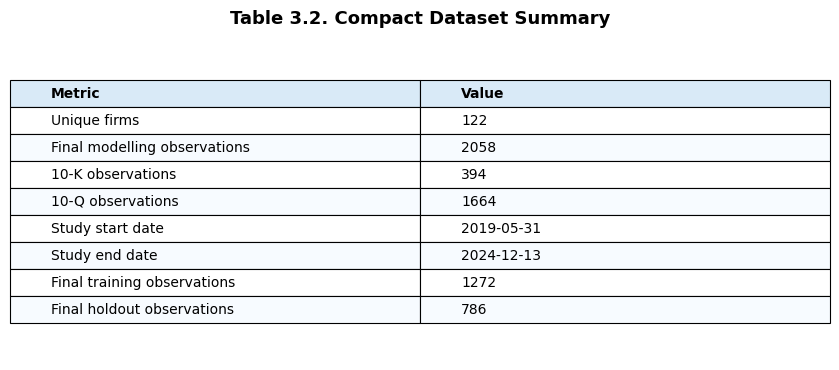

Saved as compact_dataset_summary_table.png


In [69]:
# ============================================================
# Render summary table as image
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    loc="center",
    cellLoc="left",
    colLoc="left"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAF7")
    else:
        if row % 2 == 0:
            cell.set_facecolor("#F7FBFF")
        else:
            cell.set_facecolor("white")

plt.title("Table 3.2. Compact Dataset Summary", fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("compact_dataset_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as compact_dataset_summary_table.png")

In [ ]:
# ============================================================
# Save CSV and download files
# ============================================================

summary_table.to_csv(f"{OUT_DIR}/compact_dataset_summary_table.csv", index=False)

from google.colab import files
files.download(f"{OUT_DIR}/compact_dataset_summary_table.csv")
files.download("compact_dataset_summary_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

6th visulisation

In [70]:
# ============================================================
# Visualization 6: Final main model results table
# Final version: keep full labels, improve layout
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Option A: use existing main_models_table already in memory
# ------------------------------------------------------------
try:
    display_df = main_models_table.copy()
except NameError:
    # --------------------------------------------------------
    # Option B: rebuild from final_results_df if needed
    # --------------------------------------------------------
    display_df = final_results_df.copy()

    model_label_map = {
        "NaiveMean": "Naive Mean",
        "NaiveLagVol20d": "Naive Lag Vol (20d)",
        "LinearRegression": "Linear Regression",
        "ElasticNet": "Elastic Net",
        "RandomForest": "Random Forest",
        "XGBoost": "XGBoost"
    }

    # KEEP FULL, MEANINGFUL LABELS
    specification_label_map = {
        "naive_mean": "Benchmark",
        "naive_lag_vol20d": "Benchmark",
        "model1_price_only": "Model 1: Price/Context",
        "model2_price_lm": "Model 2: Price/Context + LM",
        "model3_price_lm_finbert": "Model 3: Price/Context + LM + FinBERT PCA",
        "model4_price_lm_finbert_surprise": "Model 4: Model 3 + Surprise"
    }

    keep_rows = (
        (display_df["dataset"].isin(["naive_mean", "naive_lag_vol20d"])) |
        ((display_df["model"] == "RandomForest") & (display_df["dataset"].isin([
            "model1_price_only",
            "model2_price_lm",
            "model3_price_lm_finbert",
            "model4_price_lm_finbert_surprise"
        ]))) |
        ((display_df["model"] == "XGBoost") & (display_df["dataset"].isin([
            "model1_price_only",
            "model2_price_lm",
            "model3_price_lm_finbert",
            "model4_price_lm_finbert_surprise"
        ])))
    )

    display_df = display_df.loc[keep_rows].copy()

    display_df["Specification"] = display_df["dataset"].map(specification_label_map)
    display_df["Model"] = display_df["model"].map(model_label_map)

    specification_order = {
        "Benchmark": 1,
        "Model 1: Price/Context": 2,
        "Model 2: Price/Context + LM": 3,
        "Model 3: Price/Context + LM + FinBERT PCA": 4,
        "Model 4: Model 3 + Surprise": 5
    }

    model_order = {
        "Naive Mean": 1,
        "Naive Lag Vol (20d)": 2,
        "Random Forest": 3,
        "XGBoost": 4
    }

    display_df["spec_order"] = display_df["Specification"].map(specification_order)
    display_df["model_order"] = display_df["Model"].map(model_order)

    display_df = display_df[
        ["Specification", "Model", "RMSE_log", "MAE_log", "R2_log", "RMSE", "MAE", "R2", "spec_order", "model_order"]
    ].sort_values(["spec_order", "model_order"]).drop(columns=["spec_order", "model_order"]).reset_index(drop=True)

# ------------------------------------------------------------
# Standardise column names if already loaded from main_models_table
# ------------------------------------------------------------
rename_map = {
    "dataset_label": "Specification",
    "model_label": "Model"
}
display_df = display_df.rename(columns=rename_map)

# If existing labels are inconsistent, force full labels
display_df["Specification"] = (
    display_df["Specification"]
    .astype(str)
    .replace({
        "Model 1: Price/Context": "Model 1: Price/Context",
        "Model 2: +LM": "Model 2: Price/Context + LM",
        "Model 2: Price/Context + LM": "Model 2: Price/Context + LM",
        "Model 3: +FinBERT PCA": "Model 3: Price/Context + LM + FinBERT PCA",
        "Model 3: Price/Context + LM + FinBERT PCA": "Model 3: Price/Context + LM + FinBERT PCA",
        "Model 4: +Surprise": "Model 4: Model 3 + Surprise",
        "Model 4: Model 3 + Surprise": "Model 4: Model 3 + Surprise"
    })
)

# Keep only the final columns in the correct order
display_df = display_df[["Specification", "Model", "RMSE_log", "MAE_log", "R2_log", "RMSE", "MAE", "R2"]].copy()

# ------------------------------------------------------------
# Round values for display
# ------------------------------------------------------------
metric_cols = ["RMSE_log", "MAE_log", "R2_log", "RMSE", "MAE", "R2"]
display_df[metric_cols] = display_df[metric_cols].astype(float).round(6)

display_df

,Specification,Model,RMSE_log,MAE_log,R2_log,RMSE,MAE,R2
0,Benchmark,Naive Mean,0.555191,0.451961,-0.291755,0.010143,0.006944,-0.046412
1,Benchmark,Naive Lag Vol (20d),0.500118,0.393605,-0.048191,0.010436,0.006499,-0.107727
2,Model 1: Price/Context,Random Forest,0.441848,0.349608,0.181838,0.008814,0.005410,0.209822
3,Model 1: Price/Context,XGBoost,0.445007,0.348916,0.170095,0.008951,0.005431,0.185172
4,Model 2: Price/Context + LM,Random Forest,0.440488,0.348397,0.186867,0.008812,0.005376,0.210301
5,Model 2: Price/Context + LM,XGBoost,0.440378,0.344375,0.187271,0.008896,0.005366,0.195032
6,Model 3: Price/Context + LM + FinBERT PCA,Random Forest,0.437074,0.345732,0.199421,0.008786,0.005359,0.214823
7,Model 3: Price/Context + LM + FinBERT PCA,XGBoost,0.442560,0.345661,0.179197,0.008826,0.005383,0.207768
8,Model 4: Model 3 + Surprise,Random Forest,0.437697,0.346166,0.197135,0.008765,0.005366,0.218668
9,Model 4: Model 3 + Surprise,XGBoost,0.446646,0.351260,0.163969,0.008848,0.005478,0.203767


In [71]:
display_df.to_csv(f"{OUT_DIR}/final_main_model_results_table.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/final_main_model_results_table.csv")

Saved:
data/21_final_gold_methodology/final_main_model_results_table.csv


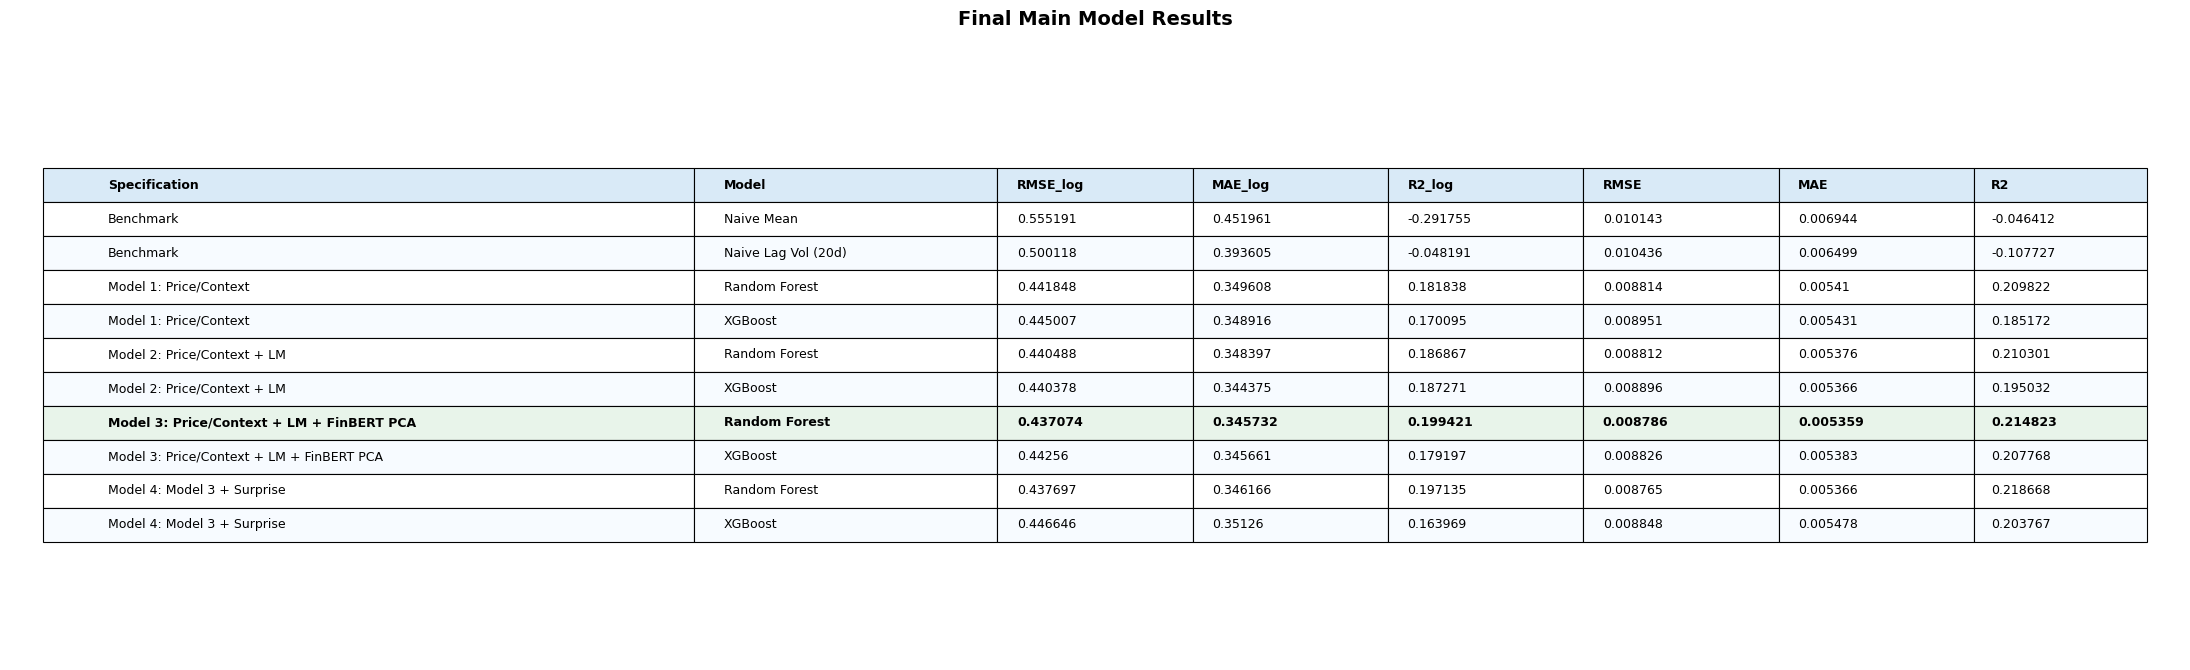

Saved as final_main_model_results_table.png


In [72]:
# ============================================================
# Render final main model results table as image
# Final version: full labels + wider column + wrapping
# Highlight main final winner row and bold all its metrics
# ============================================================

render_df = display_df.copy()

fig, ax = plt.subplots(figsize=(22, 6.8))
ax.axis("off")

# Make the Specification column wider
col_widths = [0.30, 0.14, 0.09, 0.09, 0.09, 0.09, 0.09, 0.08]

table = ax.table(
    cellText=render_df.values,
    colLabels=render_df.columns,
    loc="center",
    cellLoc="left",
    colLoc="left",
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.75)

# ------------------------------------------------------------
# Find the main final winner row
# ------------------------------------------------------------
winner_mask = (
    render_df["Specification"].astype(str).str.contains("Model 3", case=False, na=False) &
    (render_df["Model"].astype(str).str.strip() == "Random Forest")
)

if not winner_mask.any():
    print("Available Specification values:")
    print(render_df["Specification"].tolist())
    raise ValueError("Could not find the Model 3 Random Forest row. Check the Specification labels.")

winner_row_idx = render_df.index[winner_mask][0]
winner_table_row = winner_row_idx + 1  # +1 because header row is 0

# ------------------------------------------------------------
# Style cells
# ------------------------------------------------------------
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.get_text().set_wrap(True)

    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAF7")
    else:
        if row % 2 == 0:
            cell.set_facecolor("#F7FBFF")
        else:
            cell.set_facecolor("white")

# ------------------------------------------------------------
# Center numeric columns
# ------------------------------------------------------------
numeric_cols = [2, 3, 4, 5, 6, 7]
for (row, col), cell in table.get_celld().items():
    if row > 0 and col in numeric_cols:
        cell._loc = "center"

# ------------------------------------------------------------
# Highlight only the winner row
# ------------------------------------------------------------
for col in range(len(render_df.columns)):
    table[(winner_table_row, col)].set_facecolor("#E8F4EA")

# ------------------------------------------------------------
# Bold winner row labels and ALL winner row metrics
# ------------------------------------------------------------
for col in range(len(render_df.columns)):
    table[(winner_table_row, col)].set_text_props(weight="bold")

# ------------------------------------------------------------
# Title without table number
# ------------------------------------------------------------
plt.title("Final Main Model Results", fontsize=14, fontweight="bold", pad=18)

plt.tight_layout()
plt.savefig("final_main_model_results_table.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as final_main_model_results_table.png")

In [ ]:
# ============================================================
# Save CSV and download files
# ============================================================

display_df.to_csv(f"{OUT_DIR}/main_model_results_table.csv", index=False)

from google.colab import files
files.download(f"{OUT_DIR}/main_model_results_table.csv")
files.download("main_model_results_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

7th visulisation

In [73]:
# ============================================================
# Visualization 7: Model comparison bar chart
# Final version: focuses on the four main model specifications
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Option A: use existing main_models_table already in memory
# ------------------------------------------------------------
try:
    plot_df = main_models_table.copy()
except NameError:
    # --------------------------------------------------------
    # Option B: rebuild from final_results_df if needed
    # --------------------------------------------------------
    plot_df = final_results_df.copy()

    model_label_map = {
        "RandomForest": "Random Forest",
        "XGBoost": "XGBoost"
    }

    dataset_label_map = {
        "model1_price_only": "Model 1",
        "model2_price_lm": "Model 2",
        "model3_price_lm_finbert": "Model 3",
        "model4_price_lm_finbert_surprise": "Model 4"
    }

    keep_rows = (
        ((plot_df["model"] == "RandomForest") & (plot_df["dataset"].isin([
            "model1_price_only",
            "model2_price_lm",
            "model3_price_lm_finbert",
            "model4_price_lm_finbert_surprise"
        ]))) |
        ((plot_df["model"] == "XGBoost") & (plot_df["dataset"].isin([
            "model1_price_only",
            "model2_price_lm",
            "model3_price_lm_finbert",
            "model4_price_lm_finbert_surprise"
        ])))
    )

    plot_df = plot_df.loc[keep_rows].copy()
    plot_df["dataset_label"] = plot_df["dataset"].map(dataset_label_map)
    plot_df["model_label"] = plot_df["model"].map(model_label_map)

else:
    # If main_models_table exists, shorten labels for plotting
    plot_df = plot_df.copy()
    plot_df = plot_df[
        plot_df["model_label"].isin(["Random Forest", "XGBoost"])
    ].copy()

    plot_df["dataset_label"] = plot_df["dataset_label"].replace({
        "Model 1: Price/Context": "Model 1",
        "Model 2: Price/Context + LM": "Model 2",
        "Model 3: Price/Context + LM + FinBERT PCA": "Model 3",
        "Model 4: Model 3 + Surprise": "Model 4"
    })

    plot_df = plot_df[plot_df["dataset_label"].isin(["Model 1", "Model 2", "Model 3", "Model 4"])].copy()

# ------------------------------------------------------------
# Keep only needed columns
# ------------------------------------------------------------
plot_df = plot_df[["dataset_label", "model_label", "RMSE_log"]].copy()

# enforce order
dataset_order = ["Model 1", "Model 2", "Model 3", "Model 4"]
model_order = ["Random Forest", "XGBoost"]

plot_df["dataset_label"] = pd.Categorical(plot_df["dataset_label"], categories=dataset_order, ordered=True)
plot_df["model_label"] = pd.Categorical(plot_df["model_label"], categories=model_order, ordered=True)

plot_df = plot_df.sort_values(["dataset_label", "model_label"]).reset_index(drop=True)

plot_df

,dataset_label,model_label,RMSE_log
0,Model 1,Random Forest,0.441848
1,Model 1,XGBoost,0.445007
2,Model 2,Random Forest,0.440488
3,Model 2,XGBoost,0.440378
4,Model 3,Random Forest,0.437074
5,Model 3,XGBoost,0.442560
6,Model 4,Random Forest,0.437697
7,Model 4,XGBoost,0.446646


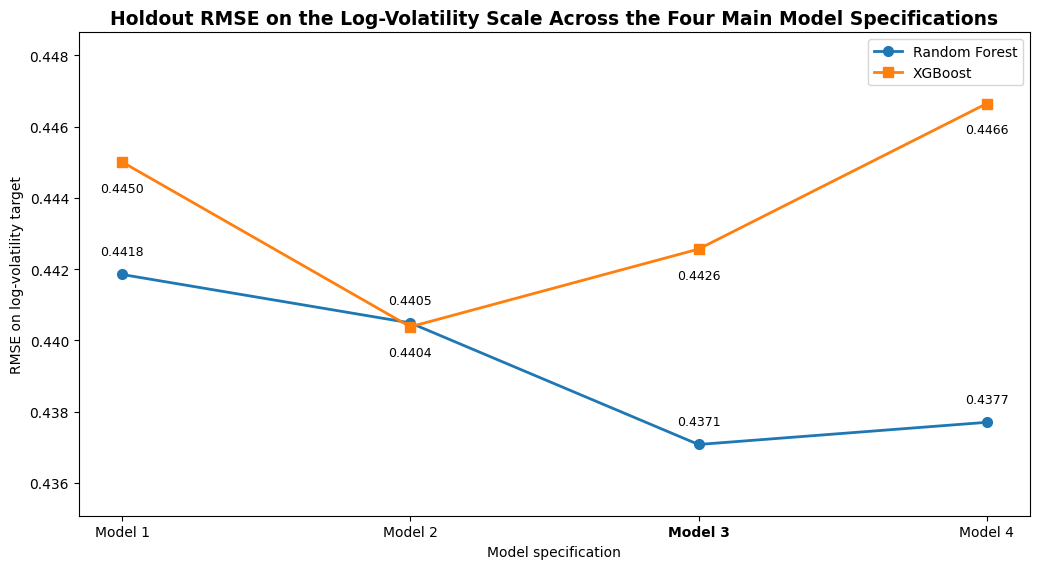

Saved as model_comparison_chart_rmse_log.png


In [74]:
# ============================================================
# Plot point-and-line comparison chart for RMSE on log target
# ============================================================

pivot_df = plot_df.pivot(index="dataset_label", columns="model_label", values="RMSE_log")

fig, ax = plt.subplots(figsize=(10.5, 5.8))

x = np.arange(len(pivot_df.index))

# plot lines with markers
ax.plot(x, pivot_df["Random Forest"], marker="o", linewidth=2, markersize=7, label="Random Forest")
ax.plot(x, pivot_df["XGBoost"], marker="s", linewidth=2, markersize=7, label="XGBoost")

# annotate exact values with cleaner formatting
for i, val in enumerate(pivot_df["Random Forest"]):
    ax.text(i, val + 0.00045, f"{val:.4f}", ha="center", va="bottom", fontsize=9)

for i, val in enumerate(pivot_df["XGBoost"]):
    ax.text(i, val - 0.00055, f"{val:.4f}", ha="center", va="top", fontsize=9)

# x-axis
ax.set_xticks(x)
ax.set_xticklabels(["Model 1", "Model 2", "Model 3", "Model 4"])

# bold Model 3 tick label
for tick in ax.get_xticklabels():
    if tick.get_text() == "Model 3":
        tick.set_fontweight("bold")

# tight y-axis so differences are visible
y_min = pivot_df.min().min()
y_max = pivot_df.max().max()
padding = 0.002

ax.set_ylim(y_min - padding, y_max + padding)

ax.set_xlabel("Model specification")
ax.set_ylabel("RMSE on log-volatility target")
ax.set_title("Holdout RMSE on the Log-Volatility Scale Across the Four Main Model Specifications",
             fontsize=13.5, fontweight="bold")
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig("model_comparison_chart_rmse_log.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as model_comparison_chart_rmse_log.png")

In [75]:
plot_df.to_csv(f"{OUT_DIR}/model_comparison_chart_rmse_log_data.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/model_comparison_chart_rmse_log_data.csv")

Saved:
data/21_final_gold_methodology/model_comparison_chart_rmse_log_data.csv


In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/model_comparison_chart_rmse_log_data.csv")
files.download("model_comparison_chart_rmse_log.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

8th visulisation

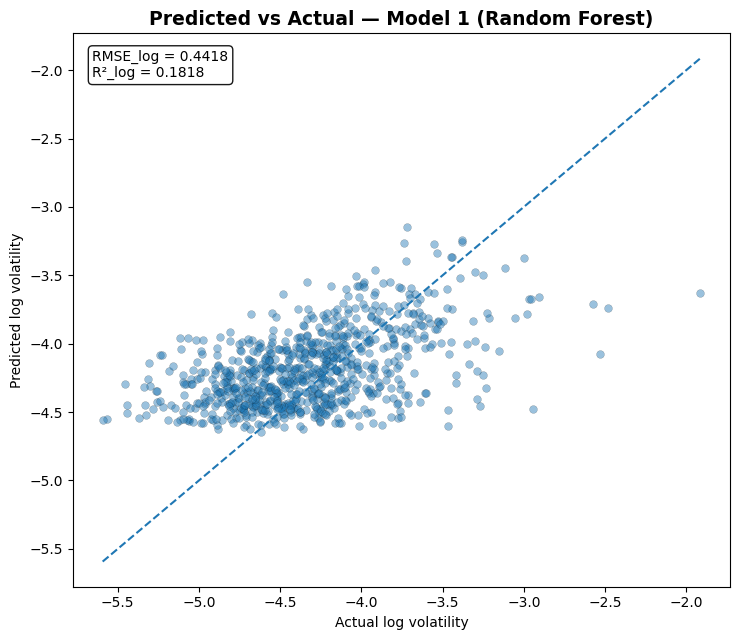

Saved as predicted_vs_actual_model1.png


In [79]:
# ============================================================
# Visualization 8: Predicted vs Actual — Model 1
# Final holdout, log-volatility target
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import r2_score, mean_squared_error

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Use final holdout data and saved final Random Forest Model 1
# Assumes these already exist from your final notebook:
# - test_final
# - saved_final_models
# - get_feature_columns(...)
# - TARGET_LOG
# ------------------------------------------------------------

plot_df = test_final.copy()

rf_model1 = saved_final_models[("RandomForest", "model1_price_only")]

X_plot = plot_df[get_feature_columns("model1_price_only")].copy()
y_true_log = plot_df[TARGET_LOG].astype(float).copy()
y_pred_log = rf_model1.predict(X_plot)

# Metrics for annotation
r2_log = r2_score(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

# ------------------------------------------------------------
# Scatter plot: predicted vs actual
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 6.5))

ax.scatter(
    y_true_log,
    y_pred_log,
    alpha=0.45,
    edgecolors="black",
    linewidths=0.2,
    s=32
)

# 45-degree reference line
xy_min = min(y_true_log.min(), y_pred_log.min())
xy_max = max(y_true_log.max(), y_pred_log.max())
ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=1.5)

ax.set_xlabel("Actual log volatility")
ax.set_ylabel("Predicted log volatility")
ax.set_title("Predicted vs Actual — Model 1 (Random Forest)",
             fontsize=13.5, fontweight="bold")

# Annotate key metrics
ax.text(
    0.03, 0.97,
    f"RMSE_log = {rmse_log:.4f}\nR²_log = {r2_log:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.9)
)

plt.tight_layout()
plt.savefig("predicted_vs_actual_model1.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as predicted_vs_actual_model1.png")

In [80]:
from google.colab import files
files.download("predicted_vs_actual_model1.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

9th visulisation

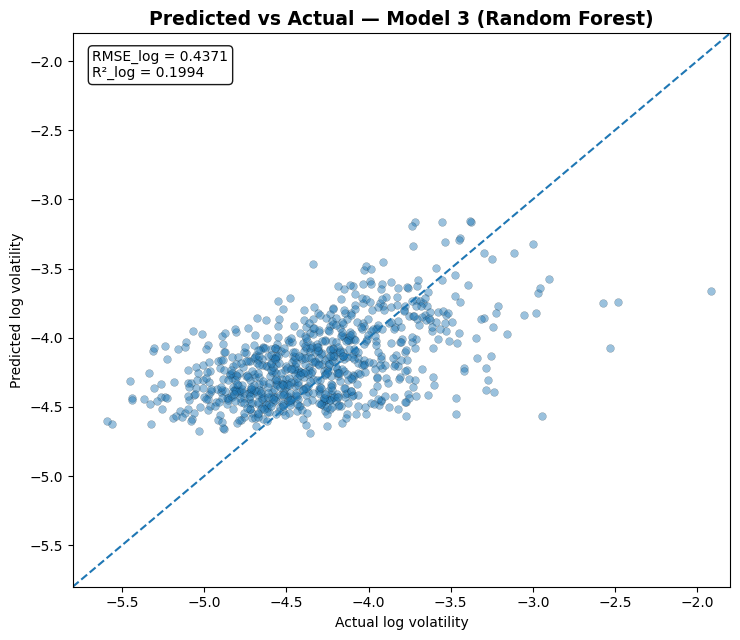

Saved as predicted_vs_actual_model3.png


In [82]:
# ============================================================
# Visualization 9: Predicted vs Actual — Model 3
# Final holdout, log-volatility target
# Final version: matched styling and fixed comparison limits
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import r2_score, mean_squared_error

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Use final holdout data and saved final Random Forest Model 3
# Assumes these already exist from your final notebook:
# - test_final
# - saved_final_models
# - get_feature_columns(...)
# - TARGET_LOG
# ------------------------------------------------------------

plot_df = test_final.copy()

rf_model3 = saved_final_models[("RandomForest", "model3_price_lm_finbert")]

X_plot = plot_df[get_feature_columns("model3_price_lm_finbert")].copy()
y_true_log = plot_df[TARGET_LOG].astype(float).copy()
y_pred_log = rf_model3.predict(X_plot)

# Metrics for annotation
r2_log = r2_score(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

# ------------------------------------------------------------
# FIXED AXIS LIMITS FOR COMPARABILITY WITH MODEL 1
# Use these same limits in both Figure 4.2 and Figure 4.3
# ------------------------------------------------------------
xy_min = min(y_true_log.min(), y_pred_log.min())
xy_max = max(y_true_log.max(), y_pred_log.max())

# Optional: if you want exact matching with Model 1,
# manually set limits after checking both figures once.
x_lower = -5.8
x_upper = -1.8
y_lower = -5.8
y_upper = -1.8

# ------------------------------------------------------------
# Scatter plot: predicted vs actual
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 6.5))

ax.scatter(
    y_true_log,
    y_pred_log,
    alpha=0.45,
    edgecolors="black",
    linewidths=0.2,
    s=32
)

# 45-degree reference line
ax.plot([x_lower, x_upper], [y_lower, y_upper], linestyle="--", linewidth=1.5)

ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)

ax.set_xlabel("Actual log volatility")
ax.set_ylabel("Predicted log volatility")
ax.set_title("Predicted vs Actual — Model 3 (Random Forest)",
             fontsize=13.5, fontweight="bold")

# Annotate key metrics
ax.text(
    0.03, 0.97,
    f"RMSE_log = {rmse_log:.4f}\nR²_log = {r2_log:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.9)
)

plt.tight_layout()
plt.savefig("predicted_vs_actual_model3.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as predicted_vs_actual_model3.png")

In [83]:
from google.colab import files
files.download("predicted_vs_actual_model3.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

10th visulisation

In [86]:
# ============================================================
# Visualization 10: Feature importance plot
# Top 15 features from the best Random Forest model
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Use existing feat_imp if already in memory
# Otherwise rebuild from saved model objects if needed
# ------------------------------------------------------------
try:
    feat_plot_df = feat_imp.copy()
except NameError:
    rf_best = saved_final_models[("RandomForest", "model3_price_lm_finbert")]
    prep = rf_best.named_steps["prep"]
    model = rf_best.named_steps["model"]

    feature_names = prep.get_feature_names_out()
    importances = model.feature_importances_

    feat_plot_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# Keep top 15 only
# ------------------------------------------------------------
feat_plot_df = feat_plot_df.head(15).copy()

In [87]:
# ============================================================
# Clean feature labels for dissertation display
# ============================================================

def clean_feature_name(name: str) -> str:
    name = str(name)

    # remove pipeline prefixes
    name = name.replace("num__", "")
    name = name.replace("cat__", "")

    # readable mappings
    mapping = {
        "mean_abs_return_10d": "Mean absolute return (10d)",
        "mean_abs_return_5d": "Mean absolute return (5d)",
        "past_realized_vol_60d": "Past realised volatility (60d)",
        "past_realized_vol_30d": "Past realised volatility (30d)",
        "past_realized_vol_20d": "Past realised volatility (20d)",
        "past_realized_vol_10d": "Past realised volatility (10d)",
        "past_return_20d": "Past return (20d)",
        "past_return_10d": "Past return (10d)",
        "past_return_5d": "Past return (5d)",
        "return_kurtosis_10d": "Return kurtosis (10d)",
        "max_abs_return_10d": "Maximum absolute return (10d)",
        "vol_ratio_10_60": "Volatility ratio (10d/60d)",
        "finbert_pca_1": "FinBERT PCA 1",
        "finbert_pca_7": "FinBERT PCA 7",
    }

    if name in mapping:
        return mapping[name]

    # filing month dummies
    if name.startswith("filing_month_"):
        month_num = name.split("_")[-1]
        month_map = {
            "1": "January", "2": "February", "3": "March", "4": "April",
            "5": "May", "6": "June", "7": "July", "8": "August",
            "9": "September", "10": "October", "11": "November", "12": "December"
        }
        month_name = month_map.get(month_num, month_num)
        return f"Filing month: {month_name}"

    # fallback
    return name.replace("_", " ").title()

feat_plot_df["feature_clean"] = feat_plot_df["feature"].apply(clean_feature_name)

# sort ascending for horizontal bar chart
feat_plot_df = feat_plot_df.sort_values("importance", ascending=True).reset_index(drop=True)

feat_plot_df[["feature_clean", "importance"]]

,feature_clean,importance
0,FinBERT PCA 7,0.015163
1,FinBERT PCA 1,0.015569
2,Filing month: February,0.017005
3,Volatility ratio (10d/60d),0.018134
4,Maximum absolute return (10d),0.018377
5,Return kurtosis (10d),0.018855
6,Past return (10d),0.021366
7,Past return (5d),0.022374
8,Past realised volatility (10d),0.022996
9,Past return (20d),0.025573


In [88]:
feat_plot_df.to_csv(f"{OUT_DIR}/feature_importance_top15_clean.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/feature_importance_top15_clean.csv")

Saved:
data/21_final_gold_methodology/feature_importance_top15_clean.csv


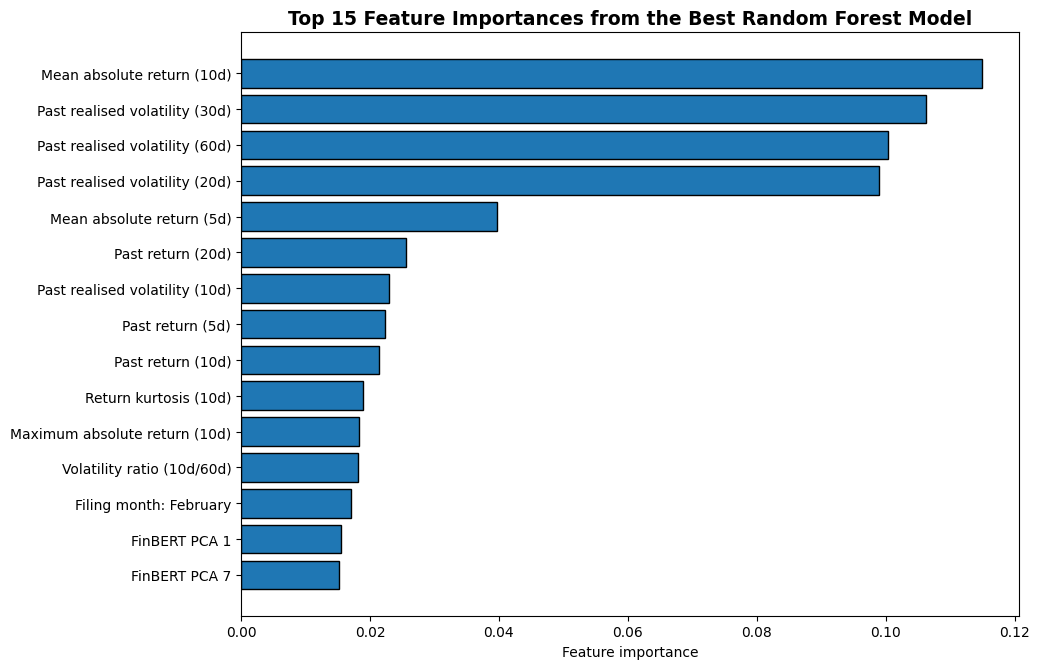

Saved as feature_importance_top15.png


In [89]:
# ============================================================
# Plot horizontal bar chart
# ============================================================

plt.figure(figsize=(10.5, 6.8))
plt.barh(feat_plot_df["feature_clean"], feat_plot_df["importance"], edgecolor="black")

plt.xlabel("Feature importance")
plt.ylabel("")
plt.title("Top 15 Feature Importances from the Best Random Forest Model",
          fontsize=13.5, fontweight="bold")

plt.tight_layout()
plt.savefig("feature_importance_top15.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as feature_importance_top15.png")

In [90]:
from google.colab import files

files.download(f"{OUT_DIR}/feature_importance_top15_clean.csv")
files.download("feature_importance_top15.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

11th visulisation

In [95]:
# ============================================================
# Visualization 11: Regime analysis chart
# Clean version using your final regime RMSE_log results
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

regime_plot_df = pd.DataFrame({
    "dataset": [
        "model4_price_lm_finbert_surprise",
        "model3_price_lm_finbert",
        "model2_price_lm",
        "model1_price_only",
        "model3_price_lm_finbert",
        "model4_price_lm_finbert_surprise",
        "model2_price_lm",
        "model1_price_only"
    ],
    "regime": [
        "high_vol",
        "high_vol",
        "high_vol",
        "high_vol",
        "low_vol",
        "low_vol",
        "low_vol",
        "low_vol"
    ],
    "RMSE_log": [
        0.448823,
        0.450456,
        0.458377,
        0.459277,
        0.434119,
        0.435249,
        0.436514,
        0.437979
    ]
})

regime_plot_df

,dataset,regime,RMSE_log
0,model4_price_lm_finbert_surprise,high_vol,0.448823
1,model3_price_lm_finbert,high_vol,0.450456
2,model2_price_lm,high_vol,0.458377
3,model1_price_only,high_vol,0.459277
4,model3_price_lm_finbert,low_vol,0.434119
5,model4_price_lm_finbert_surprise,low_vol,0.435249
6,model2_price_lm,low_vol,0.436514
7,model1_price_only,low_vol,0.437979


In [98]:
dataset_map = {
    "model1_price_only": "Model 1",
    "model3_price_lm_finbert": "Model 3",
    "model4_price_lm_finbert_surprise": "Model 4"
}

regime_map = {
    "low_vol": "Low-volatility regime",
    "high_vol": "High-volatility regime"
}

plot_df = regime_plot_df.copy()
plot_df = plot_df[plot_df["dataset"].isin(dataset_map.keys())].copy()
plot_df["dataset_label"] = plot_df["dataset"].map(dataset_map)
plot_df["regime_label"] = plot_df["regime"].map(regime_map)

pivot_df = plot_df.pivot(index="dataset_label", columns="regime_label", values="RMSE_log")

model_order = ["Model 1", "Model 3", "Model 4"]
regime_order = ["Low-volatility regime", "High-volatility regime"]

pivot_df = pivot_df.reindex(index=model_order, columns=regime_order)

pivot_df

regime_label,Low-volatility regime,High-volatility regime
dataset_label,,
Model 1,0.437979,0.459277
Model 3,0.434119,0.450456
Model 4,0.435249,0.448823


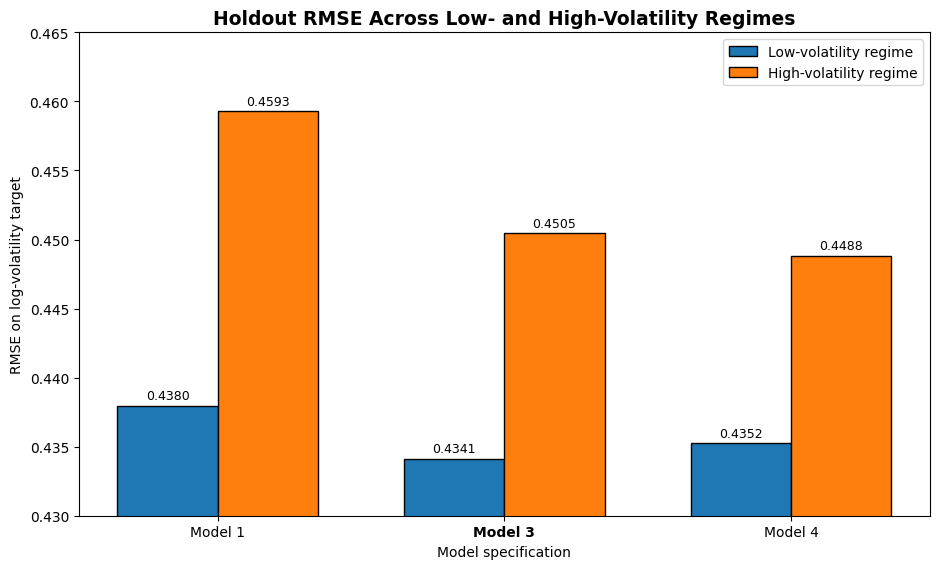

Saved as regime_analysis_chart.png


In [99]:
x = np.arange(len(pivot_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9.5, 5.8))

bars1 = ax.bar(
    x - width/2,
    pivot_df["Low-volatility regime"],
    width,
    label="Low-volatility regime",
    edgecolor="black"
)

bars2 = ax.bar(
    x + width/2,
    pivot_df["High-volatility regime"],
    width,
    label="High-volatility regime",
    edgecolor="black"
)

# Value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.00025,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.00025,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index)

# Highlight main final model
for tick in ax.get_xticklabels():
    if tick.get_text() == "Model 3":
        tick.set_fontweight("bold")

ax.set_xlabel("Model specification")
ax.set_ylabel("RMSE on log-volatility target")
ax.set_title(
    "Holdout RMSE Across Low- and High-Volatility Regimes",
    fontsize=13.5,
    fontweight="bold"
)

# Tight y-axis so differences are visible
ax.set_ylim(0.43, 0.465)

ax.legend(frameon=True)

plt.tight_layout()
plt.savefig("regime_analysis_chart.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as regime_analysis_chart.png")

In [100]:
pivot_df.to_csv(f"{OUT_DIR}/regime_analysis_chart_data.csv")

from google.colab import files
files.download(f"{OUT_DIR}/regime_analysis_chart_data.csv")
files.download("regime_analysis_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

12th visulisation

In [110]:
# ============================================================
# Visualization 12: Bootstrap confidence interval plot
# Clean self-contained version
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

bootstrap_plot_df = pd.DataFrame({
    "dataset": [
        "model3_price_lm_finbert",
        "model4_price_lm_finbert_surprise",
        "model2_price_lm",
        "model1_price_only"
    ],
    "RMSE_log_mean": [
        0.437121,
        0.437717,
        0.440593,
        0.441903
    ],
    "RMSE_log_p2_5": [
        0.414208,
        0.415239,
        0.417625,
        0.418362
    ],
    "RMSE_log_p97_5": [
        0.460896,
        0.461425,
        0.464360,
        0.465416
    ]
})

print(bootstrap_plot_df.columns.tolist())
bootstrap_plot_df

['dataset', 'RMSE_log_mean', 'RMSE_log_p2_5', 'RMSE_log_p97_5']


,dataset,RMSE_log_mean,RMSE_log_p2_5,RMSE_log_p97_5
0,model3_price_lm_finbert,0.437121,0.414208,0.460896
1,model4_price_lm_finbert_surprise,0.437717,0.415239,0.461425
2,model2_price_lm,0.440593,0.417625,0.464360
3,model1_price_only,0.441903,0.418362,0.465416


In [112]:
dataset_map = {
    "model3_price_lm_finbert": "Model 3",
    "model4_price_lm_finbert_surprise": "Model 4",
    "model2_price_lm": "Model 2",
    "model1_price_only": "Model 1"
}

plot_df = bootstrap_plot_df.copy()
plot_df["dataset_label"] = plot_df["dataset"].map(dataset_map)

plot_df = plot_df[plot_df["dataset"].isin([
    "model3_price_lm_finbert",
    "model4_price_lm_finbert_surprise"
])].copy()

order = ["Model 3", "Model 4"]
plot_df["dataset_label"] = pd.Categorical(
    plot_df["dataset_label"],
    categories=order,
    ordered=True
)

plot_df = plot_df.sort_values("dataset_label").reset_index(drop=True)

plot_df["err_lower"] = plot_df["RMSE_log_mean"] - plot_df["RMSE_log_p2_5"]
plot_df["err_upper"] = plot_df["RMSE_log_p97_5"] - plot_df["RMSE_log_mean"]

print(plot_df.columns.tolist())
plot_df

['dataset', 'RMSE_log_mean', 'RMSE_log_p2_5', 'RMSE_log_p97_5', 'dataset_label', 'err_lower', 'err_upper']


,dataset,RMSE_log_mean,RMSE_log_p2_5,RMSE_log_p97_5,dataset_label,err_lower,err_upper
0,model3_price_lm_finbert,0.437121,0.414208,0.460896,Model 3,0.022913,0.023775
1,model4_price_lm_finbert_surprise,0.437717,0.415239,0.461425,Model 4,0.022478,0.023708


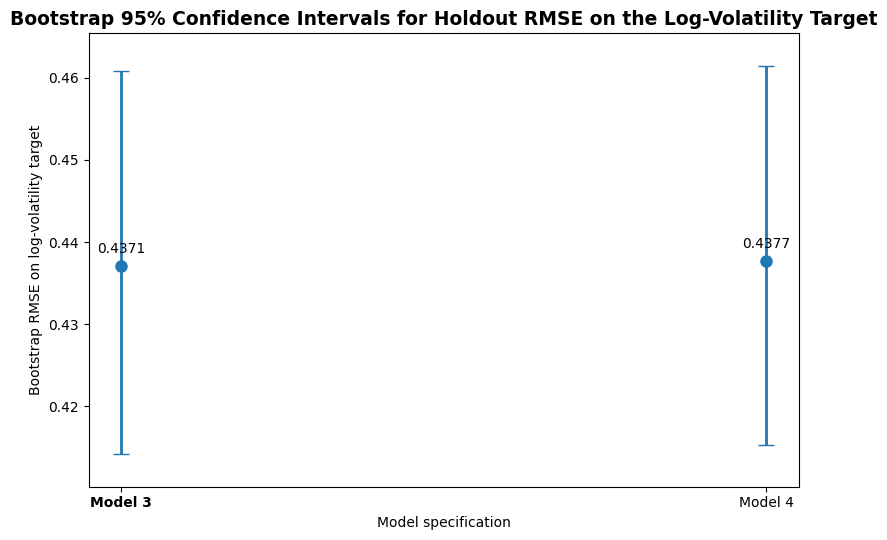

Saved as bootstrap_ci_plot.png


In [113]:
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.errorbar(
    x,
    plot_df["RMSE_log_mean"],
    yerr=[plot_df["err_lower"], plot_df["err_upper"]],
    fmt="o",
    capsize=6,
    elinewidth=2,
    markersize=8
)

for i, row in plot_df.iterrows():
    ax.text(
        i,
        row["RMSE_log_mean"] + 0.0012,
        f"{row['RMSE_log_mean']:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df["dataset_label"])

for tick in ax.get_xticklabels():
    if tick.get_text() == "Model 3":
        tick.set_fontweight("bold")

y_min = plot_df["RMSE_log_p2_5"].min()
y_max = plot_df["RMSE_log_p97_5"].max()
padding = 0.004
ax.set_ylim(y_min - padding, y_max + padding)

ax.set_xlabel("Model specification")
ax.set_ylabel("Bootstrap RMSE on log-volatility target")
ax.set_title(
    "Bootstrap 95% Confidence Intervals for Holdout RMSE on the Log-Volatility Target",
    fontsize=13.5,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("bootstrap_ci_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as bootstrap_ci_plot.png")

In [114]:
plot_df.to_csv(f"{OUT_DIR}/bootstrap_ci_plot_data.csv", index=False)

from google.colab import files
files.download(f"{OUT_DIR}/bootstrap_ci_plot_data.csv")
files.download("bootstrap_ci_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

13th visulisation

In [117]:
# ============================================================
# Visualization 13: Subgroup analysis chart
# Final version: FinBERT gains beyond LM in short vs long MD&A
# Positive values = Model 3 improves on Model 2
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Build subgroup dataframe from final reported results
# ------------------------------------------------------------
subgroup_plot_df = pd.DataFrame({
    "group": ["Short MD&A", "Long MD&A"],
    "model2_rmse_log": [0.448992, 0.429658],
    "model3_rmse_log": [0.447624, 0.423564]
})

# Positive improvement percentage:
# ((Model 2 - Model 3) / Model 2) * 100
subgroup_plot_df["model3_improvement_pct"] = (
    (subgroup_plot_df["model2_rmse_log"] - subgroup_plot_df["model3_rmse_log"])
    / subgroup_plot_df["model2_rmse_log"]
) * 100

subgroup_plot_df

,group,model2_rmse_log,model3_rmse_log,model3_improvement_pct
0,Short MD&A,0.448992,0.447624,0.304682
1,Long MD&A,0.429658,0.423564,1.418337


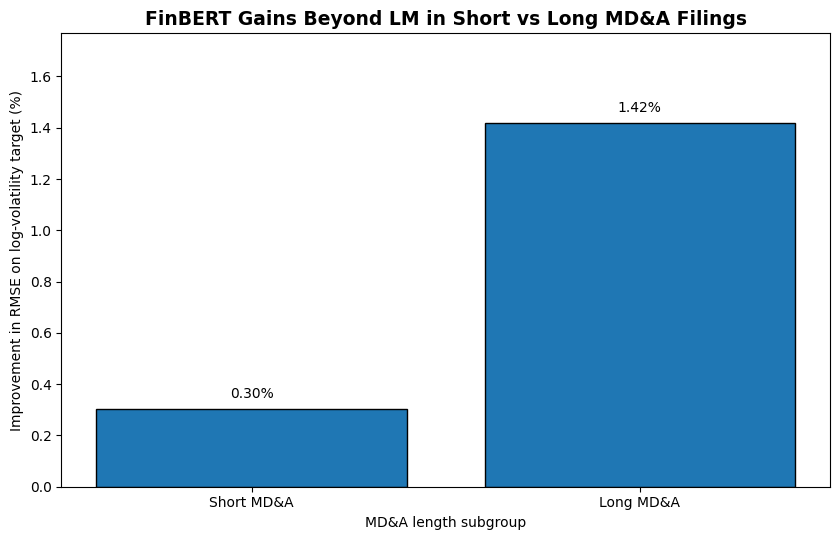

Saved as subgroup_analysis_chart_long_vs_short_mda.png


In [118]:
# ============================================================
# Plot subgroup chart
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.5))

bars = ax.bar(
    subgroup_plot_df["group"],
    subgroup_plot_df["model3_improvement_pct"],
    edgecolor="black"
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylabel("Improvement in RMSE on log-volatility target (%)")
ax.set_xlabel("MD&A length subgroup")
ax.set_title(
    "FinBERT Gains Beyond LM in Short vs Long MD&A Filings",
    fontsize=13.5,
    fontweight="bold"
)

# Optional: slight headroom
ax.set_ylim(0, subgroup_plot_df["model3_improvement_pct"].max() + 0.35)

plt.tight_layout()
plt.savefig("subgroup_analysis_chart_long_vs_short_mda.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as subgroup_analysis_chart_long_vs_short_mda.png")

In [119]:
# ============================================================
# Save CSV and download files
# ============================================================

subgroup_plot_df.to_csv(f"{OUT_DIR}/subgroup_analysis_chart_long_vs_short_mda.csv", index=False)

from google.colab import files
files.download(f"{OUT_DIR}/subgroup_analysis_chart_long_vs_short_mda.csv")
files.download("subgroup_analysis_chart_long_vs_short_mda.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

14th visulisation


In [122]:
# ============================================================
# Visualization 14: Small error analysis table
# Final cleaned version
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

error_summary_table = pd.DataFrame({
    "Scenario": [
        "Overall holdout",
        "Hard cases (top 10% baseline errors)",
        "High-volatility regime",
        "Long MD&A filings",
        "Low LM-uncertainty filings"
    ],
    "Reference model": [
        "Model 1",
        "Model 1",
        "Model 1",
        "Model 1",
        "Model 1"
    ],
    "Comparison model": [
        "Model 3",
        "Model 3",
        "Model 3",
        "Model 3",
        "Model 3"
    ],
    "Mean absolute log-error reduction": [
        0.003876,
        0.017986,
        0.013359,
        0.006364,
        0.005887
    ]
})

error_summary_table_display = error_summary_table.copy()
error_summary_table_display["Mean absolute log-error reduction"] = (
    error_summary_table_display["Mean absolute log-error reduction"].round(4)
)

error_summary_table_display

,Scenario,Reference model,Comparison model,Mean absolute log-error reduction
0,Overall holdout,Model 1,Model 3,0.0039
1,Hard cases (top 10% baseline errors),Model 1,Model 3,0.0180
2,High-volatility regime,Model 1,Model 3,0.0134
3,Long MD&A filings,Model 1,Model 3,0.0064
4,Low LM-uncertainty filings,Model 1,Model 3,0.0059


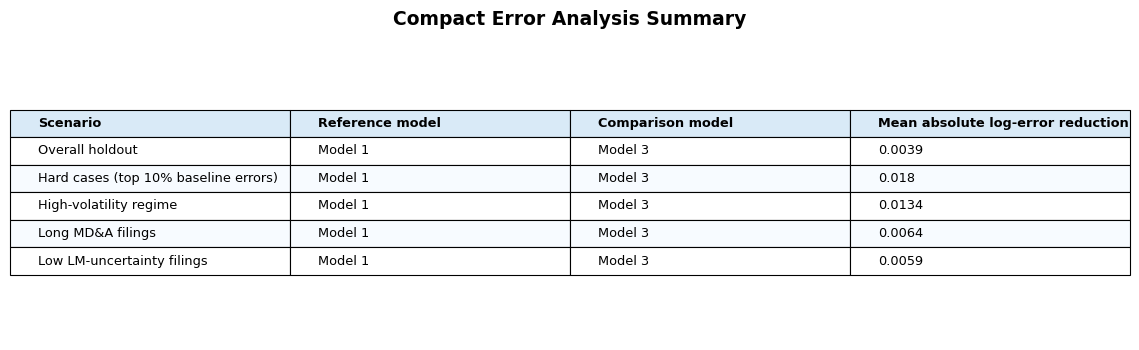

Saved as compact_error_analysis_table.png


In [124]:
fig, ax = plt.subplots(figsize=(11.5, 3.6))
ax.axis("off")

table = ax.table(
    cellText=error_summary_table_display.values,
    colLabels=error_summary_table_display.columns,
    loc="center",
    cellLoc="left",
    colLoc="left"
)

table.auto_set_font_size(False)
table.set_fontsize(9.3)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAF7")
    else:
        if row % 2 == 0:
            cell.set_facecolor("#F7FBFF")
        else:
            cell.set_facecolor("white")

plt.title("Compact Error Analysis Summary", fontsize=13.5, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("compact_error_analysis_table.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as compact_error_analysis_table.png")

In [125]:
# ============================================================
# Save CSV and download files
# ============================================================

error_summary_table.to_csv(f"{OUT_DIR}/compact_error_analysis_table.csv", index=False)

from google.colab import files
files.download(f"{OUT_DIR}/compact_error_analysis_table.csv")
files.download("compact_error_analysis_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

15th visulisation

In [128]:
# ============================================================
# Visualization 15 (optional): DM-style forecast comparison table
# Final cleaned version
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

OUT_DIR = "data/21_final_gold_methodology"
os.makedirs(OUT_DIR, exist_ok=True)

dm_table = pd.DataFrame({
    "Comparison": [
        "RF Model 1 vs RF Model 3",
        "RF Model 1 vs RF Model 3",
        "RF Model 2 vs RF Model 3",
        "RF Model 2 vs RF Model 3",
        "RF Model 3 vs RF Model 4",
        "RF Model 3 vs RF Model 4"
    ],
    "Loss type": [
        "Squared error",
        "Absolute error",
        "Squared error",
        "Absolute error",
        "Squared error",
        "Absolute error"
    ],
    "Mean loss (model 1)": [
        0.195229,
        0.349608,
        0.194029,
        0.348397,
        0.191034,
        0.345732
    ],
    "Mean loss (model 2)": [
        0.191034,
        0.345732,
        0.191034,
        0.345732,
        0.191579,
        0.346166
    ],
    "Loss diff. (m1 − m2)": [
        0.004196,
        0.003876,
        0.002996,
        0.002665,
        -0.000545,
        -0.000434
    ],
    "DM statistic": [
        2.120372,
        1.826916,
        1.652681,
        1.353662,
        -0.534395,
        -0.386729
    ],
    "p-value": [
        0.033975,
        0.067712,
        0.098396,
        0.175844,
        0.593068,
        0.698957
    ],
    "Significance": [
        "**",
        "*",
        "*",
        "",
        "",
        ""
    ]
})

dm_table_display = dm_table.copy()
num_cols = [
    "Mean loss (model 1)",
    "Mean loss (model 2)",
    "Loss diff. (m1 − m2)",
    "DM statistic",
    "p-value"
]
dm_table_display[num_cols] = dm_table_display[num_cols].round(4)

dm_table_display

,Comparison,Loss type,Mean loss (model 1),Mean loss (model 2),Loss diff. (m1 − m2),DM statistic,p-value,Significance
0,RF Model 1 vs RF Model 3,Squared error,0.1952,0.1910,0.0042,2.1204,0.0340,**
1,RF Model 1 vs RF Model 3,Absolute error,0.3496,0.3457,0.0039,1.8269,0.0677,*
2,RF Model 2 vs RF Model 3,Squared error,0.1940,0.1910,0.0030,1.6527,0.0984,*
3,RF Model 2 vs RF Model 3,Absolute error,0.3484,0.3457,0.0027,1.3537,0.1758,
4,RF Model 3 vs RF Model 4,Squared error,0.1910,0.1916,-0.0005,-0.5344,0.5931,
5,RF Model 3 vs RF Model 4,Absolute error,0.3457,0.3462,-0.0004,-0.3867,0.6990,


In [129]:
dm_table.to_csv(f"{OUT_DIR}/dm_test_summary_table.csv", index=False)

print("Saved:")
print(f"{OUT_DIR}/dm_test_summary_table.csv")

Saved:
data/21_final_gold_methodology/dm_test_summary_table.csv


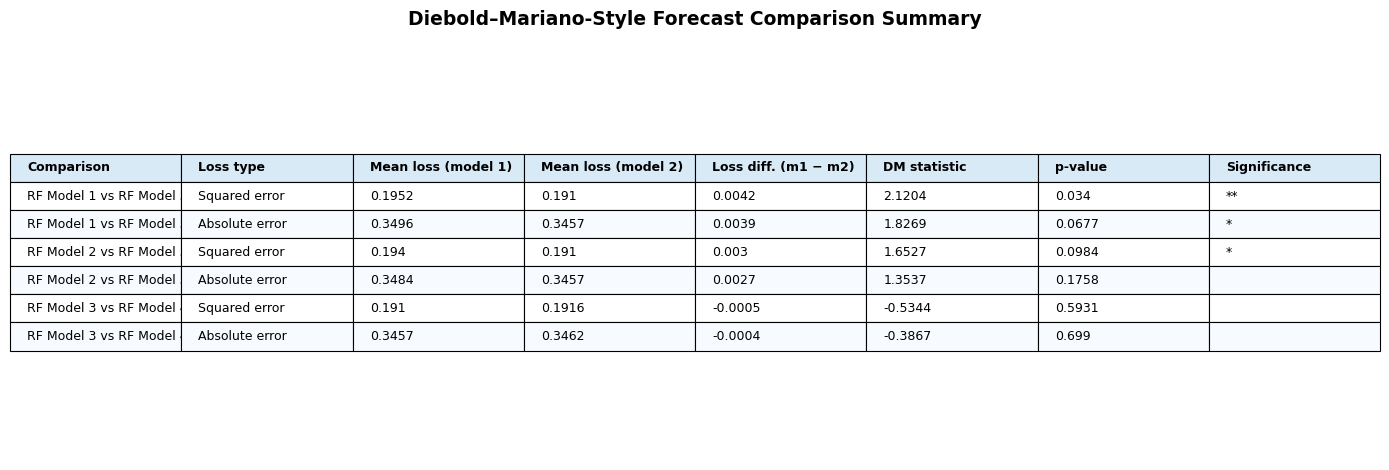

Saved as dm_test_summary_table.png


In [130]:
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.axis("off")

table = ax.table(
    cellText=dm_table_display.values,
    colLabels=dm_table_display.columns,
    loc="center",
    cellLoc="left",
    colLoc="left"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#D9EAF7")
    else:
        if row % 2 == 0:
            cell.set_facecolor("#F7FBFF")
        else:
            cell.set_facecolor("white")

plt.title(
    "Diebold–Mariano-Style Forecast Comparison Summary",
    fontsize=13.5,
    fontweight="bold",
    pad=14
)

plt.tight_layout()
plt.savefig("dm_test_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved as dm_test_summary_table.png")

In [131]:
# ============================================================
# Save CSV and download files
# ============================================================

dm_table.to_csv(f"{OUT_DIR}/dm_test_summary_table.csv", index=False)

from google.colab import files
files.download(f"{OUT_DIR}/dm_test_summary_table.csv")
files.download("dm_test_summary_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>